## 0. Setup

#### A. Install

In [3]:
!pip install --quiet --upgrade pip
!pip install --quiet hf_xet accelerate bitsandbytes datasets fast-langdetect fastexcel Levenshtein lingua-language-detector lxml matplotlib networkx numpy openpyxl optuna pandas polars pyarrow scikit-learn scipy seaborn sentencepiece torch tqdm transformers ipywidgets boto3 altair more-itertools frozendict statsmodels pymc umap-learn
!pip install --quiet -e /home/ec2-user/SageMaker/mse/

ERROR: /home/ec2-user/SageMaker/mse/ is not a valid editable requirement. It should either be a path to a local project or a VCS URL (beginning with bzr+http, bzr+https, bzr+ssh, bzr+sftp, bzr+ftp, bzr+lp, bzr+file, git+http, git+https, git+ssh, git+git, git+file, hg+file, hg+http, hg+https, hg+ssh, hg+static-http, svn+ssh, svn+http, svn+https, svn+svn, svn+file).


#### B. Packages

In [4]:
from __future__ import annotations

# Standard library imports
import json
import os
from collections import defaultdict
from itertools import pairwise

# Third-party imports
import altair as alt
import networkx as nx
import numpy as np
import optuna
import pandas as pd
import polars as pl
import regex
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from optuna import Trial
from tqdm.auto import tqdm
from matplotlib.ticker import FuncFormatter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Local imports
from mse.cdp.exploration import Exploration
from mse.cdp.merging import Merger
from mse.cdp.processing import Processor
from mse.cdp.classification import Classifier
from mse.cdp.similarity import SimilarityModel
from mse.cdp.translation import Translator
from mse.utils.io import read_csv, read_excel, read_parquet, write_csv, write_parquet
from mse.utils.cdp import DataFrame, Workbook
from mse.utils.aws import shut_down_current_sagemaker_instance

#### C. Environment

In [5]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['TOKENIZERS_PARALLELISM'] = 'true'

#### D. Globals

In [6]:
class GLOBALS:

    class inputs:
        labels              = ['investor', 'supply_chain']
        years               = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
    
    class paths:

        # | Local
        # |-------------------
        base                = '/Users/chase/Desktop/code/projects/mse/data/cdp/output'

        configs             = f'{base}/configs.json'

        raw                 = f'{base}/raw/{{label}}/{{year}}.xlsx'

        eda_sheets          = f'{base}/eda/sheets.csv'
        eda_columns         = f'{base}/eda/columns.csv'
        eda_redundant       = f'{base}/eda/redundant.csv'

        processed           = f'{base}/processed/{{label}}/{{year}}.parquet'

        mapping             = f'{base}/mapping/manual/mapping.csv'
        mapping_truth       = f'{base}/mapping/manual/mapping.csv'
        mapping_coalesced   = f'{base}/mapping/manual/coalesced.csv'

        merged              = f'{base}/merged/manual/merged.parquet'
        translated          = f'{base}/merged/manual/translated.parquet'
        classified          = f'{base}/merged/manual/classified.parquet'
        classified_chunk    = f'{base}/merged/manual/classified_{{}}.parquet'
        metrics             = f'{base}/merged/manual/metrics.parquet'
        
        # | SageMaker
        # |-------------------
        # base                = 's3://mse2024'

        # merged              = f'{base}/merged.parquet'
        # translated          = f'{base}/translated.parquet'
        # classified          = f'{base}/classified.parquet'
        # classified_chunk    = f'{base}/classified_{{}}.parquet'
        # metrics             = f'{base}/metrics.parquet'

    class models:
        eda = Exploration(
            min=2
        )
        similarity = SimilarityModel(
            model_name='sentence-transformers/all-MiniLM-L6-v2' # 'all-mpnet-base-v2'
        )
        merger = Merger(
            model=similarity,
            w_D_col=1.7,
            w_S_col=1.8,
            w_S_field=0.3,
            w_S_context=1.8,
            n_fields=4,
            win_S_context=1,
            thresh_C_method='fixed',
            thresh_C=0.24
        )
        processor = Processor(
            merger=merger,
            column_property_join = '=',
            column_property_separator = '|',
            column_suffix_special = '*'
        )
        translator = Translator(
            target='en',
            model_name='alirezamsh/small100'
        )
        classifier = Classifier(
            models=[
                ('climate_specificity', 'climatebert/distilroberta-base-climate-specificity', 'climatebert/distilroberta-base-climate-specificity'),
                ('environmental_claims', 'climatebert/environmental-claims', 'climatebert/environmental-claims'),
                ('transition', 'climatebert/transition-physical', 'climatebert/distilroberta-base-climate-detector'),
                ('climate_commitment', 'climatebert/distilroberta-base-climate-commitment', 'climatebert/distilroberta-base-climate-commitment'),
                ('tcfd', 'climatebert/distilroberta-base-climate-tcfd', 'climatebert/distilroberta-base-climate-tcfd'),
                ('climate_sentiment', 'climatebert/distilroberta-base-climate-sentiment', 'climatebert/distilroberta-base-climate-sentiment'),
                ('netzero_reduction', 'climatebert/netzero-reduction', 'climatebert/distilroberta-base-climate-f'),
                ('renewable', 'climatebert/renewable', 'climatebert/distilroberta-base-climate-detector'),
            ]
        )

    class labels:
        climate_specificity_yes = 'spec'
        climate_specificity_no = 'non'

        environmental_claims_yes = 'yes'
        environmental_claims_no = 'no'

        transition_yes = 'LABEL_1'
        transition_no = 'LABEL_0'

        climate_commitment_yes = 'yes'
        climate_commitment_no = 'no'

        tcfd_strategy = 'strategy'
        tcfd_none = 'none'
        tcfd_metrics = 'metrics'
        tcfd_risk = 'risk'
        tcfd_governance = 'governance'

        climate_sentiment_opportunity = 'opportunity'
        climate_sentiment_neutral = 'neutral'
        climate_sentiment_risk = 'risk'

        netzero_reduction_none = 'none'
        netzero_reduction_reduction = 'reduction'
        netzero_reduction_net_zero = 'net-zero'

        renewable_yes = 'LABEL_1'
        renewable_no = 'LABEL_0'

## ───────────────────────

## 1. Data

#### A. Load

In [ ]:
# | Configs
# |-------------------
with open(GLOBALS.paths.configs, 'r') as configs:
    configs = json.load(configs)
    configs = {(config['label'], config['year']): config for config in configs}

# | Workbooks
# |-------------------
workbooks = []

for year in tqdm(GLOBALS.inputs.years):
    for label in GLOBALS.inputs.labels:
        # Get the workbook data + config
        data = read_excel(GLOBALS.paths.raw.format(label=label, year=year))
        config = configs.get((label, year))

        # Create the workbook
        workbook = Workbook(
            data,
            year=config['year'],
            label=config['label'],
            join=config['join'],
            sheets=config['sheets'],
            merges=config['merges'],
            redundant=config['redundant'],
            drop=config['drop'],
            renames=config['renames']
        )
        workbooks.append(workbook)

#### B. Exploration

In [ ]:
# Filter workbooks and reinitialize
filtered = []
for workbook in workbooks:
    data = GLOBALS.models.processor._filter_workbook(workbook, workbook.sheets)
    workbook = Workbook(data, workbook.year, workbook.label, workbook.join)
    filtered.append(workbook)

# Find sheets and redundant columns
sheets = GLOBALS.models.eda.sheets(workbooks)
columns = GLOBALS.models.eda.columns(filtered)
redundant = GLOBALS.models.eda.redundant(filtered)

# Save results in parquet
write_csv(sheets, GLOBALS.paths.eda_sheets)
write_csv(columns, GLOBALS.paths.eda_columns)
write_csv(redundant, GLOBALS.paths.eda_redundant)

#### C. Optimization

In [ ]:
# | Mapping
# |-------------------
samples = GLOBALS.models.processor.process_workbooks(workbooks)

# | Manual
# |-------------------
mapping_truth = (
    read_csv(GLOBALS.paths.mapping_truth)
    .select(pl.col(f'{sample.year}_{sample.label}') for sample in samples)
    .filter(~pl.all_horizontal(pl.all().is_null()))
)

# | Optimization
# |-------------------
def evaluation_func(source, target):
    total = 0
    correct = 0

    for source_column_a, source_column_b in pairwise(source):
        target_column_a = target.get_column(source_column_a.name)
        target_column_b = target.get_column(source_column_b.name)

        source_mappings = dict(zip(source_column_a, source_column_b))
        target_mappings = dict(zip(target_column_a, target_column_b))

        for source_value_a, source_value_b in source_mappings.items():
            target_value_a = source_value_a
            target_value_b = target_mappings.get(target_value_a)

            if source_value_b and target_value_b and source_value_b == target_value_b:
                correct += 1

        total += len(source_mappings)

    return correct / total


def objective(trial: Trial):
    # Sample parameters from continuous and categorical distributions
    w_D_col = trial.suggest_float('w_D_col', 0.1, 2.0)
    w_S_col = trial.suggest_float('w_S_col', 0.1, 2.0)
    w_S_field = trial.suggest_float('w_S_field', 0.1, 2.0)
    w_S_context = trial.suggest_float('w_S_context', 0.1, 2.0)
    n_fields = trial.suggest_int('n_fields', 1, 7)
    win_S_context = trial.suggest_int('win_S_context', 1, 7)
    thresh_C_method = trial.suggest_categorical('thresh_C_method', ['fixed', 'cluster', 'spread'])
    thresh_C = trial.suggest_float('thresh_C', 0.1, 2.0)
    thresh_C_z_factor = trial.suggest_float('thresh_C_z_factor', 0.1, 2.0)
    
    # Update merger with the new parameters
    merger = Merger(
        GLOBALS.models.similarity,
        w_D_col=w_D_col,
        w_S_col=w_S_col,
        w_S_field=w_S_field,
        w_S_context=w_S_context,
        n_fields=n_fields,
        win_S_context=win_S_context,
        thresh_C_method=thresh_C_method,
        thresh_C=thresh_C,
        thresh_C_z_factor=thresh_C_z_factor
    )

    # Run the merge process (this returns merged DataFrame and mapping).
    mapping = merger.map(samples)

    # Evaluate the merged result.
    score = evaluation_func(mapping, mapping_truth)
    
    # Optuna will maximize the score.
    return score

# Create an Optuna study object and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print(f'Best Parameters: {study.best_params}\nBest Score: {study.best_value}')

## 2. Processing

#### A. Run

In [ ]:
processed = GLOBALS.models.processor.process_workbooks(workbooks)

#### B. Write

In [ ]:
for df in processed:
    write_parquet(df, GLOBALS.paths.processed.format(label=df.label, year=df.year))

## 3. Merging

#### X. Manual

In [ ]:
# | 1. Collect data
# |-------------------

dfs = []
for workbook in tqdm(workbooks, desc='Processing workbooks'):
    wb = GLOBALS.models.processor._filter_workbook(workbook, workbook.sheets)
    df = GLOBALS.models.processor._join_workbook(wb, workbook.join)
    df = GLOBALS.models.processor._clean_fields(df)
    df = GLOBALS.models.processor._drop_columns(df, [])

    df = DataFrame(df, year=workbook.year, label=workbook.label)
    dfs.append(df)

In [ ]:
# | 2. Create mapping
# |-------------------

mapping = (
    pl.read_csv(GLOBALS.paths.mapping)

    # Combine column and sheet values
    .with_columns(
        pl.concat_str(
            pl.col(f'{year}__{label}__column'),
            pl.col(f'{year}__{label}__sheet'),
            separator='__'
        ).alias(f'{year}_{label}')
        for year in GLOBALS.inputs.years for label in GLOBALS.inputs.labels
    )

    # Only keep new combined columns
    .select(
        pl.col(f'{year}_{label}')
        for year in GLOBALS.inputs.years for label in GLOBALS.inputs.labels
    )

    # Keep rows that don't have all values null
    .filter(~pl.all_horizontal(pl.all().is_null()))

    # Convert to standardized format
    .with_columns(
        pl.all().map_elements(
            lambda col: GLOBALS.models.processor.create_column(
                {'column': col.split('__')[0], 'sheet': col.split('__')[1], 'value': 'response'},
            ),
            return_dtype=pl.String
        )
    )
)

# Verify that all mapping columns contain unique values
for col in mapping:
    clean = col.drop_nulls()
    if len(clean.unique()) != len(clean):
        counts = clean.value_counts().filter(pl.col('count') > 1)
        print(f'ERROR: {col.name} contains non-unique values:')
        print(counts)

# Coalesce the mapping
mapping_coalesced = (
    mapping
    .select(mapping.columns[::-1])
    .with_columns(pl.coalesce(pl.all()).alias('column'))
    .select(pl.col('column'))
    .to_series()
)

# Make the columns unique by adding number properties
mapping_coalesced = (
    pl.DataFrame(mapping_coalesced)
    .with_row_index('order')
    .group_by('column')
    .agg(pl.len().alias('number'), 'order')
    .with_columns(pl.col('order').list.first())
    .with_columns(pl.int_ranges(0, pl.col('number')).alias('number'))
    .explode('number')
    .sort('order')
    .map_rows(lambda x: GLOBALS.models.processor.update_column(x[0], {'number': str(x[1])}) if x[1] > 0 else x[0], return_dtype=pl.String)
    .get_column('map')
)

In [ ]:
# | 3. Merge data
# |-------------------

# Define metadata columns for the output dataframe
year_column = 'column=year|sheet=*|value=meta'
label_column = 'column=label|sheet=*|value=meta'

# Vertical stack the dataframes
merged = []

for df in dfs:
    mapping_column = mapping.get_column(df.name)

    # Get mapping from old to new columns
    column_mapping = {old: new for old, new in zip(mapping_column, mapping_coalesced) if old}

    # Find columns in column mapping that aren't in the dataframe
    for col in column_mapping.keys():
        if col not in df.columns:
            print(f'{df.name} — ERROR: `{col}` not found')

    # Update dataframe
    df = (
        df
        # Select columns from mapping column, since the mapping column leaves out some columns
        .select(column_mapping.keys())

        # Rename the columns
        .rename(column_mapping)

        # Add meta columns
        .with_columns(
            pl.lit(df.year).alias(year_column),
            pl.lit(df.label).alias(label_column)
        )

        # Reorder columns
        .select(year_column, label_column, pl.exclude(year_column, label_column))
    )

    merged.append(df)

# Cast to standard type
merged = pl.concat(merged, how='diagonal_relaxed').cast(pl.List(pl.String))

#### A. Load

In [ ]:
processed = read_parquet(GLOBALS.paths.processed)

#### B. Run

In [ ]:
merged, mapping = GLOBALS.models.merger.merge(processed)

#### C. Write

In [ ]:
write_parquet(merged, GLOBALS.paths.merged)
write_csv(mapping, GLOBALS.paths.mapping)

#### D. Coalesce

In [ ]:
# Coalesce column names in mapping
coalesced_rows = []
for row in list(mapping.iter_rows(named=True)):
    coalesced_row = {}
    row_items = list(row.items())[::-1]

    for i, (k, v) in enumerate(row_items):
        if v and not coalesced_row:
            coalesced_row['column'] = v
            coalesced_row['to'] = k

        elif (not v and coalesced_row) or (i == len(row_items) - 1 and coalesced_row):
            coalesced_row['from'] = row_items[i - 1][0]
            break
    
    coalesced_rows.append(coalesced_row)

mapping_coalesced = pl.DataFrame(coalesced_rows)

# Write coalesced mapping to dataframe
write_csv(mapping_coalesced, GLOBALS.paths.mapping_coalesced)

## ───────────────────────

## 4. Columns

#### A. Load

In [ ]:
merged = read_parquet(GLOBALS.paths.merged)

#### B. Filter

In [ ]:
frq = defaultdict(list)
year = 'column=year|sheet=*|value=meta'

for col in merged.columns:

    # Skip the year column
    if col in [year]:
        continue

    # Get the groups by year
    groups = (
        merged
        .select(year, col)
        .with_columns(pl.col(year).list.first())
        .explode(col)
        .drop_nulls(col)
        .group_by(year)
    )

    # Get the values for the column
    values = merged.get_column(col).drop_nulls().explode()

    # Check if there are values
    if values.is_empty():
        frq['column'].append(None)
        frq['number values'].append(None)
        frq['number unique values'].append(None)
        frq['average number unique values across years'].append(None)
        frq['proportion unique'].append(None)
        frq['average length'].append(None)
        frq['length range'].append(None)
        frq['punctuation contained'].append(None)
        frq['values contain other number'].append(None)
        frq['samples'].append(None)
        continue

    # Check proportion of unique values to values
    number_values = values.len()
    number_unique_values = values.unique().len()
    average_number_unique_values_across_years = groups.agg(pl.col(col).unique().len()).mean().get_column(col).item()
    proportion_unique = values.unique().len() / values.len()
    average_length = values.str.len_chars().mean()
    length_range = values.str.len_chars().min(), values.str.len_chars().max()
    punctuation_contained = pl.Series(regex.findall(r'\p{P}', values.str.concat('').item())).unique().drop_nulls().to_list() or None
    values_contain_other_number = sum(values.str.count_matches(p).sum() for p in [r'^Other:\s', r'^Other,\s'])
    samples = values.value_counts(sort=True, name='count')
    samples = pl.concat((samples.slice(0, 3), samples.slice(-3, 3)), how='vertical')
    samples = samples.with_columns(pl.concat_str(pl.col('count'), pl.col(col), separator='|').alias('samples')).get_column('samples')
    samples = samples.str.slice(0, 30).to_list()

    # Append responses to the dataframe
    frq['column'].append(col)
    frq['number values'].append(number_values)
    frq['number unique values'].append(number_unique_values)
    frq['average number unique values across years'].append(average_number_unique_values_across_years)
    frq['proportion unique'].append(proportion_unique)
    frq['average length'].append(average_length)
    frq['length range'].append(length_range)
    frq['punctuation contained'].append(punctuation_contained)
    frq['values contain other number'].append(values_contain_other_number)
    frq['samples'].append(samples)

frq = pl.DataFrame(frq)

In [ ]:
filtered = (
    frq
    .filter(
        (pl.col('values contain other number') > 0) |
        (
            (pl.col('punctuation contained').list.len() > 0) &
            (pl.col('punctuation contained').list.contains('.')) &
            (pl.col('punctuation contained').list.contains(',')) &
            (pl.col('average length') > 20) &
            (pl.col('average number unique values across years') > 1) &
            (pl.col('length range').list.last() > 30)
        )
    )
    .with_columns(pl.col(pl.List(pl.String)).list.join('    ·    '))
)

RESPONSE_COLUMNS = GLOBALS.models.processor.filter_columns(merged.columns, {'value': 'response'})

FREE_RESPONSE_COLUMNS = filtered.get_column('column').to_list()

## ───────────────────────

## 5. Translation

#### A. Load

In [ ]:
merged = read_parquet(GLOBALS.paths.merged)
translate = merged.select(merged.columns) # FREE_RESPONSE_COLUMNS

#### B. Run

In [ ]:
translated = GLOBALS.models.translator.translate_df(translate, processor=GLOBALS.models.processor, extends=False, detected=False, progress=True, batch_size=64)

In [ ]:
translated = merged.with_columns(translated)

#### C. Write

In [ ]:
write_parquet(translated, GLOBALS.paths.translated)

## 6. Classification

#### A. Load

In [ ]:
translated = read_parquet(GLOBALS.paths.translated)
classify = translated.select(translated.columns) # FREE_RESPONSE_COLUMNS

#### B. Run

In [ ]:
classified = GLOBALS.models.classifier.classify_df(classify, processor=GLOBALS.models.processor, extends=True, batch_size=512, progress=True, chunk_path=GLOBALS.paths.classified_chunk, chunk_makedirs=False)

In [ ]:
classified = translated.with_columns(classified)

#### C. Write

In [ ]:
write_parquet(classified, GLOBALS.paths.classified)

## 7. Metrics

#### A. Load

In [ ]:
classified = read_parquet(GLOBALS.paths.classified)

#### B. Run

In [ ]:
columns = []

# Define important function aliases
update_column = GLOBALS.models.processor.update_column
create_column = GLOBALS.models.processor.create_column

# Create expressions for each response column
for col in GLOBALS.models.processor.filter_columns(classified.columns, {'value': 'response'}):

    # Define original and new column names
    specificity_column_name = update_column(col, {'model': 'climate_specificity', 'label': GLOBALS.labels.climate_specificity_yes, 'value': 'score'})
    average_specificity_column_name = update_column(col, {'model': 'climate_specificity', 'label': GLOBALS.labels.climate_specificity_yes, 'value': 'score_average'})
    response_length_column_name = update_column(col, {'value': 'number_characters'})
    number_responses_column_name = update_column(col, {'value': 'number_responses'})

    # Create expressions
    average_specificity_column = (
        pl.col(specificity_column_name)
        .list.drop_nulls()
        .cast(pl.List(pl.Float64))
        .list.mean()
        .alias(average_specificity_column_name)
    )
    response_length_column = (
        pl.col(col)
        .list.drop_nulls()
        .cast(pl.List(pl.String))
        .list.join('', ignore_nulls=True)
        .str.len_chars()
        .alias(response_length_column_name)
    )
    number_responses_column = (
        pl.col(col)
        .list.drop_nulls()
        .list.len()
        .alias(number_responses_column_name)
    )

    # Add column expressions
    columns.extend((average_specificity_column, response_length_column, number_responses_column))

# Add expressions
metrics = classified.with_columns(columns)

# # Add aggregate metrics
# response_columns_free_specificity_scores = [GLOBALS.models.processor.update_column(col, {'model': 'climate_specificity', 'label': GLOBALS.labels.climate_specificity_yes, 'value': 'score'}) for col in RESPONSE_COLUMNS_FREE]
# response_columns_free_num_chars = [GLOBALS.models.processor.update_column(col, {'value': 'num_chars'}) for col in RESPONSE_COLUMNS_FREE]
# response_columns_num_responses = [GLOBALS.models.processor.update_column(col, {'value': 'num_responses'}) for col in RESPONSE_COLUMNS]

# response_columns_free_specificity_scores_average_name = GLOBALS.models.processor.create_column({'column': 'free_response', 'sheet': GLOBALS.models.processor.column_suffix_special, 'model': 'climate_specificity', 'label': GLOBALS.labels.climate_specificity_yes, 'value': 'average_score'})
# response_columns_free_num_chars_total_name = GLOBALS.models.processor.create_column({'column': 'free_response', 'sheet': GLOBALS.models.processor.column_suffix_special, 'value': 'num_chars'})
# response_columns_num_responses_total_name = GLOBALS.models.processor.create_column({'column': 'any_response', 'sheet': GLOBALS.models.processor.column_suffix_special, 'value': 'num_responses'})
# response_columns_num_questions_responded_total_name = GLOBALS.models.processor.create_column({'column': 'any_response', 'sheet': GLOBALS.models.processor.column_suffix_special, 'value': 'num_questions_responded'})

# metrics = metrics.with_columns(
#     pl.concat_list(response_columns_free_specificity_scores).list.drop_nulls().cast(pl.List(pl.Float64)).list.mean().alias(response_columns_free_specificity_scores_average_name),
#     pl.concat_list(response_columns_free_num_chars).list.sum().alias(response_columns_free_num_chars_total_name),
#     pl.concat_list(response_columns_num_responses).list.sum().alias(response_columns_num_responses_total_name),
#     pl.concat_list(response_columns_num_responses).list.eval(pl.when(pl.element() >= 1).then(1).otherwise(0)).list.sum().alias(response_columns_num_questions_responded_total_name),
# )

#### C. Write

In [ ]:
write_parquet(metrics.with_columns(merged), GLOBALS.paths.metrics)

## ───────────────────────

## 8. Analysis

#### A. Load

In [7]:
metrics = read_parquet(GLOBALS.paths.metrics)

In [8]:
# Only consider investor responses to avoid double counting
metrics = metrics.filter(pl.col('column=label|sheet=*|value=meta').list.contains('investor'))

# Clean and modify columns of the dataframe
columns = []
for column in metrics.select(pl.selectors.by_dtype(pl.List(pl.String))):

    # Turn single element list columns into string columns
    if column.drop_nulls().list.len().eq(1).all():
        column = column.explode().cast(pl.String)

    # Turn string columns that contain into float columns
    if column.dtype.base_type().is_(pl.String):
        column_casted = column.cast(pl.Float64, strict=False)

    # Turn all list columns that contain strings into numeric
    elif column.dtype.is_(pl.List(pl.String)):
        column_casted = column.cast(pl.List(pl.Float64), strict=False)

    # Check if the cast was successful, then replace the original column
    if column.explode().null_count() == column_casted.explode().null_count():
        column = column_casted

    # Append final transformed column
    columns.append(column)

# Replace original columns with transformed columns
metrics = metrics.with_columns(columns)

#### B. Constants

In [ ]:
# | Columns
# |-------------------
LABEL_COLUMN = 'column=label|sheet=*|value=meta'
YEAR_COLUMN = 'column=year|sheet=*|value=meta'
ACCOUNT_NUMBER_COLUMN = 'column=Account number|sheet=*|value=response'
CURRENCY_COLUMN = 'column=C0.4_Select the currency used for all financial information disclosed throughout your response.|sheet=C0 - Introduction|value=response'
PAYBACK_PERIOD_COLUMN = 'column=C4.3b_C7_Provide details on the initiatives implemented in the reporting year in the table below. - Payback period|sheet=C4.3b|value=response'
INITIATIVES_INVESTMENT_COLUMN = 'column=C4.3b_C6_Provide details on the initiatives implemented in the reporting year in the table below. - Investment required (unit currency – as specified in C0.4)|sheet=C4.3b|value=response'
INTENSITY_TARGET_FIGURE_COLUMN_PER_CURRENCY = 'column=CC12.2 C1 - Please describe your gross global combined Scope 1 and 2 emissions for the reporting year in metric tonnes CO2e per unit currency total revenue - Intensity figure =|sheet=CC12.2|value=response'
INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY = 'column=C4.1b_C14_Provide details of your emissions intensity target(s) and progress made against those target(s). - Intensity figure in reporting year (metric tons CO2e per unit of activity)|sheet=C4.1b|value=response'
INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN = 'column=C4.1b_C15_Provide details of your emissions intensity target(s) and progress made against those target(s). - % of target achieved [auto-calculated]|sheet=C4.1b|value=response'
TARGETED_REDUCTION_COLUMN = 'column=C4.1b_C10_Provide details of your emissions intensity target(s) and progress made against those target(s). - Targeted reduction from base year (%)|sheet=C4.1b|value=response'
YEAR_TARGET_SET_COLUMN = 'column=C4.1b_C2_Provide details of your emissions intensity target(s) and progress made against those target(s). - Year target was set|sheet=C4.1b|value=response'

# | Mappings
# |-------------------
# Mapping to convert currency codes to standardized format
CURRENCY_RENAMES = {
    'XXX'       : 'USD',
    'USN'       : 'USD',
    'EUR(€)'    : 'EUR',
    'GBP(£)'    : 'GBP',
    'JPY(¥)'    : 'JPY',
    'CAD ($)'   : 'CAD',
    'AUD ($)'   : 'AUD',
    'NZD ($)'   : 'NZD',
    'CNY(¥)'    : 'CNY',
    'INR(Rp)'   : 'INR',
    'SGD ($)'   : 'SGD',
    'ARS($)'    : 'ARS',
    'BRL(R$)'   : 'BRL',
    'MXN ($)'   : 'MXN',
    'ZAR (R)'   : 'ZAR',
    'USD($)'    : 'USD',
    'CHW'       : 'CHF',
}

# Historical exchange rates 2010 to 2020 IMF World Bank major currencies
EXCHANGE_RATES_PATH = '/Users/chase/Desktop/code/projects/mse/data/cdp/output/exchange_rates.csv'
EXCHANGE_RATES = read_csv(EXCHANGE_RATES_PATH).rows_by_key(key='year', named=True, unique=True)

#### C. Initiatives Investment vs. Payback Period

##### I. Standardize Currencies

In [14]:
converted = (
    metrics

    # Select columns of interest
    .select(
        ACCOUNT_NUMBER_COLUMN,
        YEAR_COLUMN,
        CURRENCY_COLUMN,
        PAYBACK_PERIOD_COLUMN,
        INITIATIVES_INVESTMENT_COLUMN
    )

    # Drop rows where the number of payback periods is not equal to the number of investments
    .filter(pl.col(PAYBACK_PERIOD_COLUMN).list.len() == pl.col(INITIATIVES_INVESTMENT_COLUMN).list.len())

    # Explode list fields
    .explode(PAYBACK_PERIOD_COLUMN, INITIATIVES_INVESTMENT_COLUMN)

    # Only select company rows where all three are provided
    .filter(
        pl.col(CURRENCY_COLUMN).is_not_null() &
        pl.col(PAYBACK_PERIOD_COLUMN).is_not_null() &
        pl.col(INITIATIVES_INVESTMENT_COLUMN).is_not_null()
    )

    # Drop rows where initiatives investment is not a value
    .filter(~pl.col(INITIATIVES_INVESTMENT_COLUMN).str.to_lowercase().is_in(['hidden answer', 'question not applicable']))

    # Drop payback period rows where question is not applicable
    .filter(~pl.col(PAYBACK_PERIOD_COLUMN).str.to_lowercase().is_in(['hidden answer', 'question not applicable']))

    # Convert initiatives investment to float
    .with_columns(pl.col(INITIATIVES_INVESTMENT_COLUMN).cast(pl.Float64, strict=True))

    # Drop initiatives where the amount invested is zero
    .filter(pl.col(INITIATIVES_INVESTMENT_COLUMN) > 0)

    # Rename currencies to standardized
    .with_columns(pl.col(CURRENCY_COLUMN).replace(CURRENCY_RENAMES))

    # Correct mistakes in disclosures
    .with_columns(pl.when((pl.col(ACCOUNT_NUMBER_COLUMN) == 20893) & (pl.col(YEAR_COLUMN) == 2017)).then(pl.lit('JPY')).otherwise(pl.col(CURRENCY_COLUMN)).alias(CURRENCY_COLUMN))

    # Convert currencies to USD
    .with_columns(
        pl.struct(YEAR_COLUMN, CURRENCY_COLUMN, INITIATIVES_INVESTMENT_COLUMN)
        .map_elements(
            lambda struct:
            struct[INITIATIVES_INVESTMENT_COLUMN] / EXCHANGE_RATES[struct[YEAR_COLUMN]][struct[CURRENCY_COLUMN]],
            return_dtype=pl.Float64
        )
        .alias(INITIATIVES_INVESTMENT_COLUMN)
    )

    # Create our own categories: <1 year, 1-3 years, >3 years
    .with_columns(
        pl.col(PAYBACK_PERIOD_COLUMN)
        .replace(['4-10 years', '4 - 10 years', '11-15 years', '21-25 years', '>25 years', '16-20 years'], '>3 years')
        .replace(None, 'No payback')
    )
)

# converted

##### II. Sample Investment Amounts vs. Time

In [ ]:
start, end = 90, 100

selected = (
    # Group by year and account number
    converted
    .select(YEAR_COLUMN, ACCOUNT_NUMBER_COLUMN, INITIATIVES_INVESTMENT_COLUMN)
    .group_by(ACCOUNT_NUMBER_COLUMN, YEAR_COLUMN)
    .agg(pl.col(INITIATIVES_INVESTMENT_COLUMN).sum())
    .sort(by=ACCOUNT_NUMBER_COLUMN)

    # Select range of companies from start to end
    .filter(
        pl.col(ACCOUNT_NUMBER_COLUMN).is_in(
            converted
            .select(ACCOUNT_NUMBER_COLUMN).unique(maintain_order=True)
            .slice(start, end - start).get_column(ACCOUNT_NUMBER_COLUMN)
        )
    )

    # Rename columns for clarity
    .rename({
        YEAR_COLUMN: 'Year',
        ACCOUNT_NUMBER_COLUMN: 'Account',
        INITIATIVES_INVESTMENT_COLUMN: 'Total Investment (USD)'
    })
)

alt.Chart(selected).mark_line().encode(
    x=alt.X(shorthand='Year', scale=alt.Scale(domain=[2010, 2020])),
    y=alt.Y(shorthand='Total Investment (USD)'),
    color='Account:N'
).interactive()

alt.Chart(...)

##### III. Comprehensive Analysis

In [ ]:
# Rename the columns for easier access
df = converted.rename({
    PAYBACK_PERIOD_COLUMN: "payback_period",
    INITIATIVES_INVESTMENT_COLUMN: "investment_required"
})

# Set up a better figure size and style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (20, 16)
plt.rcParams['font.size'] = 12

# Create a formatter for axis labels (to display large numbers in K, M format)
def millions_formatter(x, pos):
    if x == 0:
        return '0'
    elif abs(x) >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif abs(x) >= 1e3:
        return f'${x*1e-3:.1f}K'
    else:
        return f'${x:.1f}'

formatter = FuncFormatter(millions_formatter)

# Define order for payback periods for consistent plotting
payback_order = ['<1 year', '1-3 years', '>3 years', 'No payback']

# Create a grid for our visualizations
fig = plt.figure(figsize=(20, 25))
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1. Distribution of Initiatives by Year
ax1 = fig.add_subplot(gs[0, 0])
year_counts = df.group_by(YEAR_COLUMN).agg(pl.len().alias('count')).sort(YEAR_COLUMN)
year_counts_pd = year_counts.to_pandas()
# Updated barplot syntax
sns.barplot(data=year_counts_pd, x=YEAR_COLUMN, y='count', ax=ax1, hue=YEAR_COLUMN, palette='viridis', legend=False)
ax1.set_title('Number of Initiatives by Year', fontsize=16)
ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Number of Initiatives', fontsize=14)
ax1.tick_params(axis='x', rotation=0)

# 2. Distribution of Payback Periods
ax2 = fig.add_subplot(gs[0, 1])
payback_counts = df.group_by('payback_period').agg(pl.len().alias('count'))
# Convert to pandas for categorical ordering
payback_counts_pd = payback_counts.to_pandas()
payback_counts_pd['payback_period'] = pd.Categorical(
    payback_counts_pd['payback_period'], 
    categories=payback_order, 
    ordered=True
)
payback_counts_pd = payback_counts_pd.sort_values('payback_period')
# Updated barplot syntax
sns.barplot(data=payback_counts_pd, x='payback_period', y='count', ax=ax2, hue='payback_period', palette='viridis', legend=False)
ax2.set_title('Distribution of Payback Periods', fontsize=16)
ax2.set_xlabel('Payback Period', fontsize=14)
ax2.set_ylabel('Number of Initiatives', fontsize=14)
ax2.tick_params(axis='x', rotation=45)

# 3. Distribution of Investment Amounts (Histogram)
ax3 = fig.add_subplot(gs[1, 0])
# Filter in Polars then convert only what's needed for plotting
investment_data = df.filter(pl.col('investment_required') > 0).select('investment_required').to_pandas()
sns.histplot(investment_data, ax=ax3, bins=30, kde=True, log_scale=True)
ax3.set_title('Distribution of Investment Amounts (Log Scale)', fontsize=16)
ax3.set_xlabel('Investment Required (USD, Log Scale)', fontsize=14)
ax3.set_ylabel('Frequency', fontsize=14)
ax3.xaxis.set_major_formatter(formatter)

# 4. Box Plot of Investment by Payback Period
ax4 = fig.add_subplot(gs[1, 1])
# Calculate 99th percentile in Polars
investment_threshold = df.filter(pl.col('investment_required') > 0).select(
    pl.col('investment_required').quantile(0.99)
).item()
# Filter data in Polars
filtered_df = df.filter(
    (pl.col('investment_required') > 0) & 
    (pl.col('investment_required') <= investment_threshold)
)
# Convert to pandas for categorical ordering
filtered_pd = filtered_df.to_pandas()
filtered_pd['payback_period'] = pd.Categorical(
    filtered_pd['payback_period'], 
    categories=payback_order, 
    ordered=True
)
# Updated boxplot syntax
sns.boxplot(data=filtered_pd, x='payback_period', y='investment_required', ax=ax4, hue='payback_period', palette='viridis', legend=False)
ax4.set_title('Investment Amount by Payback Period (Excluding Outliers)', fontsize=16)
ax4.set_xlabel('Payback Period', fontsize=14)
ax4.set_ylabel('Investment Required (USD)', fontsize=14)
ax4.yaxis.set_major_formatter(formatter)
ax4.tick_params(axis='x', rotation=45)

# 5. Trend of Investments Over Years (Mean and Median)
ax5 = fig.add_subplot(gs[2, 0])
yearly_investment = df.filter(pl.col('investment_required') > 0).group_by(YEAR_COLUMN).agg(
    pl.col('investment_required').mean().alias('mean_investment'),
    pl.col('investment_required').median().alias('median_investment')
).sort(YEAR_COLUMN)
yearly_investment_pd = yearly_investment.to_pandas()
ax5.plot(yearly_investment_pd[YEAR_COLUMN], yearly_investment_pd['mean_investment'], marker='o', label='Mean Investment')
ax5.plot(yearly_investment_pd[YEAR_COLUMN], yearly_investment_pd['median_investment'], marker='s', label='Median Investment')
ax5.set_title('Average Investment Amount by Year', fontsize=16)
ax5.set_xlabel('Year', fontsize=14)
ax5.set_ylabel('Investment Amount (USD)', fontsize=14)
ax5.yaxis.set_major_formatter(formatter)
ax5.legend()
ax5.grid(True)

# 6. Stacked Bar Chart - Payback Period Distribution by Year
ax6 = fig.add_subplot(gs[2, 1])
payback_by_year = df.group_by([YEAR_COLUMN, 'payback_period']).agg(pl.len().alias('count')).to_pandas()
# Pivot the data for stacked bar chart
payback_pivot = payback_by_year.pivot(index=YEAR_COLUMN, columns='payback_period', values='count').fillna(0)
# Reorder columns
payback_pivot = payback_pivot.reindex(columns=payback_order)
payback_pivot.plot(kind='bar', stacked=True, ax=ax6, colormap='viridis')
ax6.set_title('Distribution of Payback Periods by Year', fontsize=16)
ax6.set_xlabel('Year', fontsize=14)
ax6.set_ylabel('Number of Initiatives', fontsize=14)
ax6.legend(title='Payback Period')

# 7. Heatmap - Correlation between Year, Payback Period, and Investment
# Convert payback period to numeric for correlation
payback_map = {'<1 year': 1, '1-3 years': 2, '>3 years': 3, 'No payback': 4}
# Create a temporary pandas DF for correlation
correlation_data_pd = df.to_pandas()
correlation_data_pd['payback_numeric'] = correlation_data_pd['payback_period'].map(payback_map)
correlation_matrix = correlation_data_pd[[YEAR_COLUMN, 'payback_numeric', 'investment_required']].corr()

ax7 = fig.add_subplot(gs[3, 0])
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=ax7)
ax7.set_title('Correlation Matrix', fontsize=16)

# 8. Scatter Plot: Investment Amount vs. Payback Period
ax8 = fig.add_subplot(gs[3, 1])
sns.scatterplot(data=filtered_pd, x='investment_required', y='payback_period', 
                hue=YEAR_COLUMN, palette='viridis', alpha=0.7, ax=ax8)
ax8.set_title('Investment Amount vs. Payback Period', fontsize=16)
ax8.set_xlabel('Investment Required (USD)', fontsize=14)
ax8.set_ylabel('Payback Period', fontsize=14)
ax8.xaxis.set_major_formatter(formatter)
ax8.legend(title='Year')

# 9. Average Investment by Payback Period and Year
investment_by_payback_year = df.filter(pl.col('investment_required') > 0).group_by([YEAR_COLUMN, 'payback_period']).agg(
    pl.col('investment_required').mean().alias('mean_investment')
).sort([YEAR_COLUMN, 'payback_period']).to_pandas()

# Create categorical order
investment_by_payback_year['payback_period'] = pd.Categorical(
    investment_by_payback_year['payback_period'], 
    categories=payback_order, 
    ordered=True
)

ax9 = fig.add_subplot(gs[4, 0:])
sns.barplot(data=investment_by_payback_year, x=YEAR_COLUMN, y='mean_investment', 
            hue='payback_period', palette='viridis', ax=ax9)
ax9.set_title('Average Investment by Payback Period and Year', fontsize=16)
ax9.set_xlabel('Year', fontsize=14)
ax9.set_ylabel('Mean Investment (USD)', fontsize=14)
ax9.yaxis.set_major_formatter(formatter)
ax9.legend(title='Payback Period')

# Handle tight_layout warning by using fig.tight_layout() instead
fig.tight_layout(pad=2.0, h_pad=3.0, w_pad=3.0)
plt.show()

# Time Series Decomposition plots
# Create a datetime for visualization purposes
df_time = df.with_columns(pl.col(YEAR_COLUMN).cast(pl.Date).alias('date'))
investment_time_series = df_time.group_by('date').agg(
    pl.col('investment_required').mean().alias('mean'),
    pl.col('investment_required').median().alias('median'),
    pl.len().alias('count')
).sort('date').to_pandas()

plt.figure(figsize=(15, 10))
plt.subplot(3, 1, 1)
plt.plot(investment_time_series['date'], investment_time_series['mean'], marker='o')
plt.title('Mean Investment Over Time')
plt.ylabel('Mean Investment (USD)')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(investment_time_series['date'], investment_time_series['median'], marker='o', color='orange')
plt.title('Median Investment Over Time')
plt.ylabel('Median Investment (USD)')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(investment_time_series['date'], investment_time_series['count'], marker='o', color='green')
plt.title('Number of Initiatives Over Time')
plt.ylabel('Count')
plt.grid(True)

plt.tight_layout(pad=2.0)
plt.show()

# Violin plot of investment by payback period
plt.figure(figsize=(15, 10))
# Updated violinplot syntax
sns.violinplot(data=filtered_pd, x='payback_period', y='investment_required', hue='payback_period', palette='viridis', legend=False)
plt.title('Distribution of Investment Amounts by Payback Period', fontsize=16)
plt.xlabel('Payback Period', fontsize=14)
plt.ylabel('Investment Required (USD)', fontsize=14)
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid(True)
plt.show()

# Stacked area chart of investment proportion by payback period over time
investment_proportion = df.group_by([YEAR_COLUMN, 'payback_period']).agg(
    pl.col('investment_required').sum().alias('total_investment')
).to_pandas()

# Pivot to get years as rows and payback periods as columns
investment_pivot = investment_proportion.pivot(index=YEAR_COLUMN, columns='payback_period', values='total_investment').fillna(0)
investment_pivot = investment_pivot.reindex(columns=payback_order)

# Calculate proportions
investment_prop = investment_pivot.div(investment_pivot.sum(axis=1), axis=0)

# Plot
plt.figure(figsize=(15, 10))
investment_prop.plot(kind='area', stacked=True, colormap='viridis')
plt.title('Proportion of Total Investment by Payback Period Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Proportion of Investment', fontsize=14)
plt.grid(True)
plt.legend(title='Payback Period')
plt.show()

# Investment quartile analysis
# Create investment quartiles using Polars
quartile_labels = ['Q1 (Smallest)', 'Q2', 'Q3', 'Q4 (Largest)']
df_with_quartiles = df.with_columns(
    pl.when(pl.col('investment_required') <= pl.col('investment_required').quantile(0.25))
    .then(pl.lit(quartile_labels[0]))
    .when(pl.col('investment_required') <= pl.col('investment_required').quantile(0.5))
    .then(pl.lit(quartile_labels[1]))
    .when(pl.col('investment_required') <= pl.col('investment_required').quantile(0.75))
    .then(pl.lit(quartile_labels[2]))
    .otherwise(pl.lit(quartile_labels[3]))
    .alias('investment_quartile')
)

# Convert to pandas for visualization
payback_by_quartile = df_with_quartiles.to_pandas().groupby(['investment_quartile', 'payback_period']).size().unstack(fill_value=0)
payback_by_quartile_pct = payback_by_quartile.div(payback_by_quartile.sum(axis=1), axis=0) * 100

# Plot this distribution
plt.figure(figsize=(15, 10))
payback_by_quartile_pct.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Payback Period Distribution by Investment Size Quartile', fontsize=16)
plt.xlabel('Investment Size Quartile', fontsize=14)
plt.ylabel('Percentage of Initiatives', fontsize=14)
plt.legend(title='Payback Period')
plt.grid(True)
plt.show()

# Evolution of payback periods over time
years = sorted(df.select(pl.col(YEAR_COLUMN).unique()).to_series().to_list())
strategy_shifts = pd.DataFrame(index=years)

# Calculate metrics using Polars
for year in years:
    year_data = df.filter(pl.col(YEAR_COLUMN) == year)
    year_count = year_data.height
    
    # Average investment size
    strategy_shifts.loc[year, 'avg_investment'] = year_data.select(pl.col('investment_required').mean()).item()
    
    # Proportion of initiatives with each payback period
    for period in payback_order:
        period_count = year_data.filter(pl.col('payback_period') == period).height
        strategy_shifts.loc[year, f'pct_{period.replace(" ", "_")}'] = period_count / year_count * 100

# Plot evolution of investment strategies
plt.figure(figsize=(15, 10))
for period in payback_order:
    column_name = f'pct_{period.replace(" ", "_")}'
    plt.plot(strategy_shifts.index, strategy_shifts[column_name], marker='o', label=period)

plt.title('Evolution of Payback Period Distribution Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Percentage of Initiatives', fontsize=14)
plt.grid(True)
plt.legend(title='Payback Period')
plt.show()


==== ADVANCED STATISTICAL ANALYSIS ====


/Users/chase/Desktop/code/projects/mse/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/chase/Desktop/code/projects/mse/venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/chase/Desktop/code/projects/mse/venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/chase/Desktop/code/projects/mse/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred fr

ValueError: Asymmetrical error bars should be provided with the shape (2, 2)

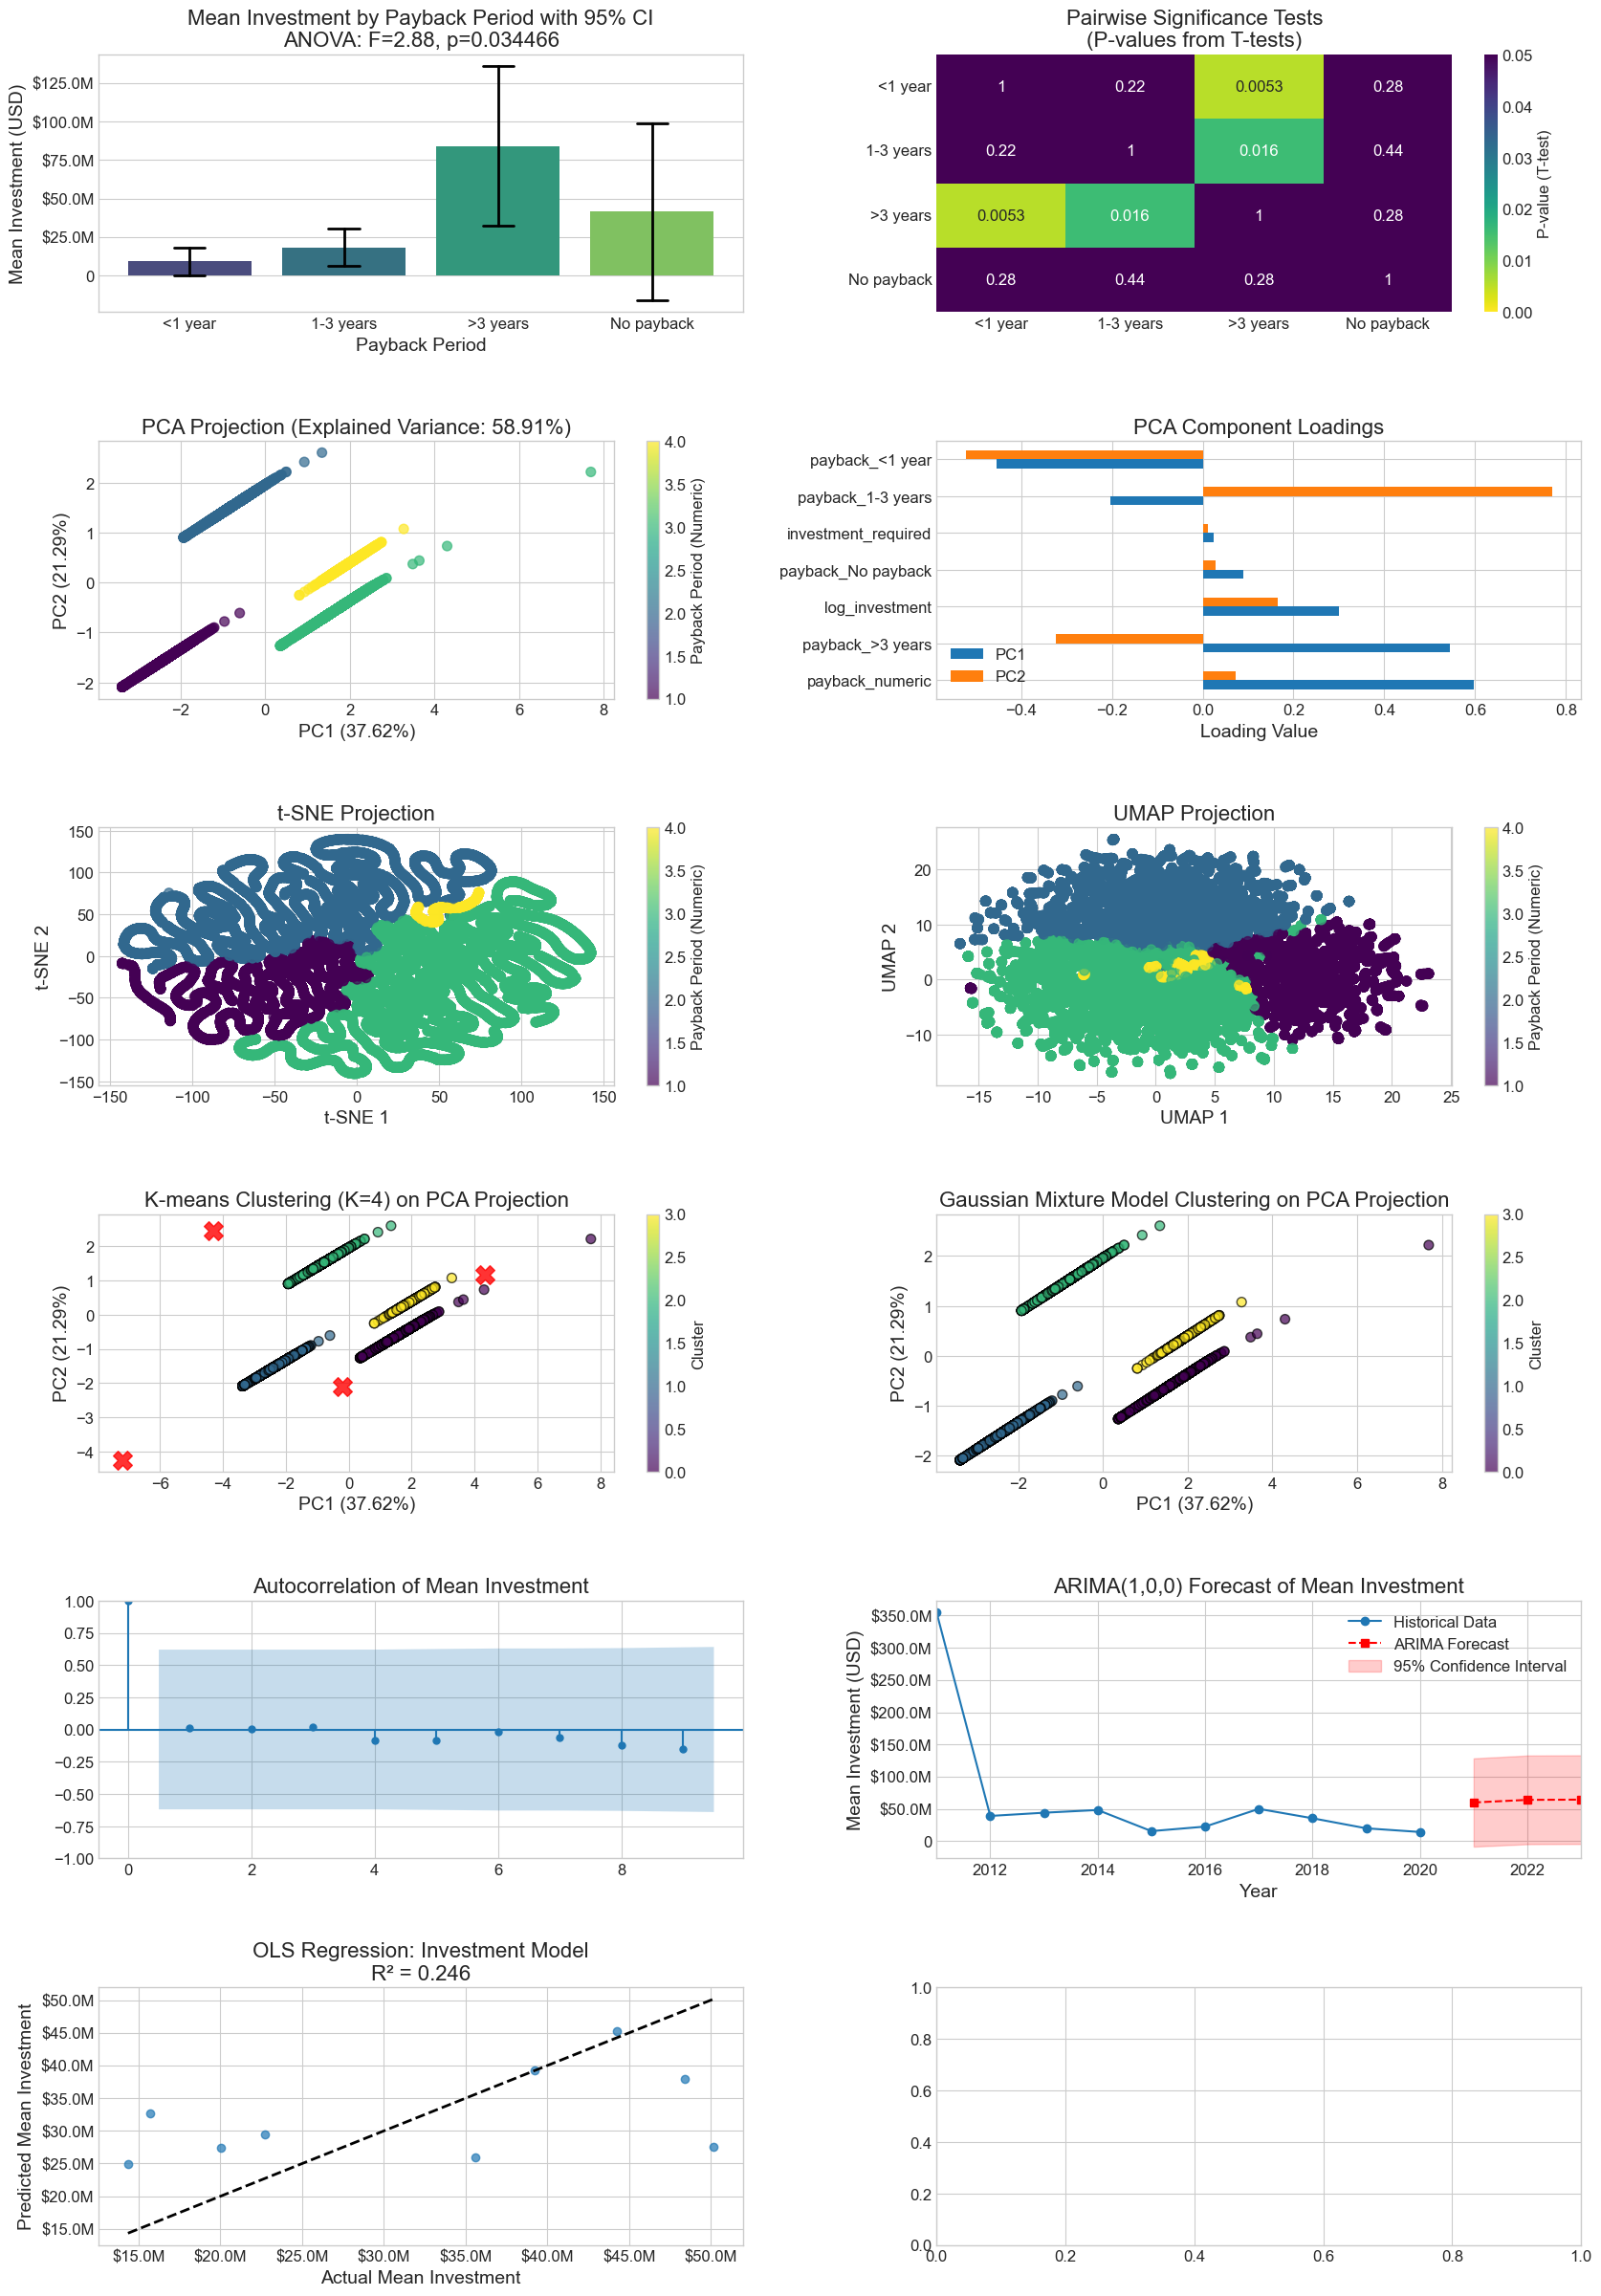

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import numpy as np
import polars as pl
import pandas as pd
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
import pymc as pm
import arviz as az
import statsmodels.api as sm
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway
import networkx as nx
from umap import UMAP

# Original visualization code (unchanged)
# [I'm assuming all the previous visualization code from my answer is here]

# ============ ADVANCED ANALYSIS SECTION ============

# 1. STATISTICAL HYPOTHESIS TESTING
print("\n==== ADVANCED STATISTICAL ANALYSIS ====")

# Create a figure for advanced analysis results
fig_advanced = plt.figure(figsize=(20, 35))
gs_advanced = gridspec.GridSpec(7, 2, figure=fig_advanced, hspace=0.5, wspace=0.3)

df = converted.rename({
    PAYBACK_PERIOD_COLUMN: "payback_period",
    INITIATIVES_INVESTMENT_COLUMN: "investment_required"
})

# A. Statistical Tests on Investment by Payback Period
# Convert to pandas for statistical testing
df_pandas = df.to_pandas()

# Create groups by payback period
groups = [df_pandas[df_pandas['payback_period'] == period]['investment_required'].dropna() 
          for period in payback_order]

# ANOVA test to check for significant differences between groups
f_stat, p_value = f_oneway(*groups)

# Create visualization of means with confidence intervals
ax_stats = fig_advanced.add_subplot(gs_advanced[0, 0])
ci_data = []
for period in payback_order:
    group_data = df_pandas[df_pandas['payback_period'] == period]['investment_required']
    mean = group_data.mean()
    ci = stats.t.interval(0.95, len(group_data)-1, loc=mean, scale=stats.sem(group_data))
    ci_data.append([period, mean, ci[0], ci[1]])

ci_df = pd.DataFrame(ci_data, columns=['period', 'mean', 'ci_lower', 'ci_upper'])
sns.barplot(data=ci_df, x='period', y='mean', ax=ax_stats, hue='period', palette='viridis', legend=False)
for i, row in ci_df.iterrows():
    ax_stats.plot([i, i], [row['ci_lower'], row['ci_upper']], color='black', linewidth=2)
    ax_stats.plot([i-0.1, i+0.1], [row['ci_lower'], row['ci_lower']], color='black', linewidth=2)
    ax_stats.plot([i-0.1, i+0.1], [row['ci_upper'], row['ci_upper']], color='black', linewidth=2)

ax_stats.set_title(f'Mean Investment by Payback Period with 95% CI\nANOVA: F={f_stat:.2f}, p={p_value:.6f}', fontsize=16)
ax_stats.set_xlabel('Payback Period', fontsize=14)
ax_stats.set_ylabel('Mean Investment (USD)', fontsize=14)
ax_stats.yaxis.set_major_formatter(formatter)

# B. Post-hoc pairwise tests
ax_posthoc = fig_advanced.add_subplot(gs_advanced[0, 1])
# Perform pairwise t-tests with Bonferroni correction
num_tests = len(payback_order) * (len(payback_order) - 1) // 2
pairwise_results = []

for i, period1 in enumerate(payback_order):
    for j, period2 in enumerate(payback_order[i+1:], i+1):
        group1 = df_pandas[df_pandas['payback_period'] == period1]['investment_required'].dropna()
        group2 = df_pandas[df_pandas['payback_period'] == period2]['investment_required'].dropna()
        
        # T-test
        t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
        
        # Mann-Whitney U test (non-parametric alternative)
        u_stat, mw_p_val = mannwhitneyu(group1, group2, alternative='two-sided')
        
        # Store results
        pairwise_results.append([f"{period1} vs {period2}", t_stat, p_val, p_val*num_tests < 0.05, 
                                mw_p_val, mw_p_val*num_tests < 0.05])

# Create results table
pairwise_df = pd.DataFrame(pairwise_results, 
                          columns=['Comparison', 'T-stat', 'P-value', 'Significant (Bonferroni)', 
                                  'MW P-value', 'MW Significant (Bonferroni)'])

# Visualize as a heatmap for p-values
heatmap_data = np.ones((len(payback_order), len(payback_order)))
for i, period1 in enumerate(payback_order):
    for j, period2 in enumerate(payback_order):
        if i < j:
            row = pairwise_df[pairwise_df['Comparison'] == f"{period1} vs {period2}"]
            if not row.empty:
                heatmap_data[i, j] = row['P-value'].values[0]
                heatmap_data[j, i] = row['P-value'].values[0]
        elif i == j:
            heatmap_data[i, j] = 1.0

# Plot significance heatmap
sns.heatmap(heatmap_data, annot=True, cmap='viridis_r', vmin=0, vmax=0.05, 
            xticklabels=payback_order, yticklabels=payback_order, ax=ax_posthoc,
            cbar_kws={'label': 'P-value (T-test)'})
ax_posthoc.set_title('Pairwise Significance Tests\n(P-values from T-tests)', fontsize=16)

# 2. DIMENSIONALITY REDUCTION AND PATTERN RECOGNITION
# Create a rich feature set
df_features = df.to_pandas()

# Generate additional engineered features for better pattern recognition
df_features['log_investment'] = np.log1p(df_features['investment_required'])
df_features['payback_numeric'] = df_features['payback_period'].map(payback_map)

# One-hot encode categorical variables
payback_dummies = pd.get_dummies(df_features['payback_period'], prefix='payback')
df_features = pd.concat([df_features, payback_dummies], axis=1)

# Prepare feature matrix for dimensionality reduction
feature_cols = ['investment_required', 'log_investment', 'payback_numeric'] + list(payback_dummies.columns)
X = df_features[feature_cols].copy()

# Handle missing values
X = X.fillna(X.median())

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# A. Principal Component Analysis
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Plot PCA results
ax_pca = fig_advanced.add_subplot(gs_advanced[1, 0])
scatter = ax_pca.scatter(pca_result[:, 0], pca_result[:, 1], c=df_features['payback_numeric'], 
                        cmap='viridis', alpha=0.7, s=50)
ax_pca.set_title(f'PCA Projection (Explained Variance: {pca.explained_variance_ratio_.sum():.2%})', fontsize=16)
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=14)
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=14)
ax_pca.grid(True)
plt.colorbar(scatter, ax=ax_pca, label='Payback Period (Numeric)')

# Show PCA component loadings
ax_pca_components = fig_advanced.add_subplot(gs_advanced[1, 1])
component_df = pd.DataFrame(pca.components_.T, index=feature_cols, columns=['PC1', 'PC2'])
component_df = component_df.sort_values('PC1', ascending=False)
component_df.plot(kind='barh', ax=ax_pca_components)
ax_pca_components.set_title('PCA Component Loadings', fontsize=16)
ax_pca_components.set_xlabel('Loading Value', fontsize=14)
ax_pca_components.grid(True)

# B. t-SNE for non-linear dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_scaled)-1))
tsne_result = tsne.fit_transform(X_scaled)

ax_tsne = fig_advanced.add_subplot(gs_advanced[2, 0])
scatter = ax_tsne.scatter(tsne_result[:, 0], tsne_result[:, 1], c=df_features['payback_numeric'], 
                         cmap='viridis', alpha=0.7, s=50)
ax_tsne.set_title('t-SNE Projection', fontsize=16)
ax_tsne.set_xlabel('t-SNE 1', fontsize=14)
ax_tsne.set_ylabel('t-SNE 2', fontsize=14)
ax_tsne.grid(True)
plt.colorbar(scatter, ax=ax_tsne, label='Payback Period (Numeric)')

# C. UMAP projection (more modern than t-SNE)
umap_model = UMAP(n_components=2, random_state=42, min_dist=0.1, n_neighbors=min(15, len(X_scaled)-1))
umap_result = umap_model.fit_transform(X_scaled)

ax_umap = fig_advanced.add_subplot(gs_advanced[2, 1])
scatter = ax_umap.scatter(umap_result[:, 0], umap_result[:, 1], c=df_features['payback_numeric'], 
                         cmap='viridis', alpha=0.7, s=50)
ax_umap.set_title('UMAP Projection', fontsize=16)
ax_umap.set_xlabel('UMAP 1', fontsize=14)
ax_umap.set_ylabel('UMAP 2', fontsize=14)
ax_umap.grid(True)
plt.colorbar(scatter, ax=ax_umap, label='Payback Period (Numeric)')

# 3. UNSUPERVISED LEARNING AND CLUSTER ANALYSIS
# A. K-means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

ax_kmeans = fig_advanced.add_subplot(gs_advanced[3, 0])
scatter = ax_kmeans.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans_labels, 
                          cmap='viridis', alpha=0.7, s=50, edgecolor='k')
# Plot cluster centers
centers = pca.transform(scaler.transform(kmeans.cluster_centers_))
ax_kmeans.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X')
ax_kmeans.set_title('K-means Clustering (K=4) on PCA Projection', fontsize=16)
ax_kmeans.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=14)
ax_kmeans.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=14)
ax_kmeans.grid(True)
plt.colorbar(scatter, ax=ax_kmeans, label='Cluster')

# B. Gaussian Mixture Model
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

ax_gmm = fig_advanced.add_subplot(gs_advanced[3, 1])
scatter = ax_gmm.scatter(pca_result[:, 0], pca_result[:, 1], c=gmm_labels, 
                        cmap='viridis', alpha=0.7, s=50, edgecolor='k')
ax_gmm.set_title('Gaussian Mixture Model Clustering on PCA Projection', fontsize=16)
ax_gmm.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=14)
ax_gmm.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=14)
ax_gmm.grid(True)
plt.colorbar(scatter, ax=ax_gmm, label='Cluster')

# Analyze clusters
df_features['kmeans_cluster'] = kmeans_labels
df_features['gmm_cluster'] = gmm_labels

# 4. TIME SERIES ANALYSIS AND FORECASTING
# Extract time series data for investment trends
yearly_series = df.group_by(YEAR_COLUMN).agg(
    pl.col('investment_required').mean().alias('mean_investment'),
    pl.col('investment_required').sum().alias('total_investment'),
    pl.len().alias('count')
).sort(YEAR_COLUMN).to_pandas()

# Convert to proper time series
yearly_series['date'] = pd.to_datetime(yearly_series[YEAR_COLUMN], format='%Y')
yearly_series = yearly_series.set_index('date')

# A. Autocorrelation analysis
ax_acf = fig_advanced.add_subplot(gs_advanced[4, 0])
plot_acf(yearly_series['mean_investment'].dropna(), ax=ax_acf, lags=min(10, len(yearly_series)-1))
ax_acf.set_title('Autocorrelation of Mean Investment', fontsize=16)

# B. ARIMA forecasting
# Fit ARIMA model
try:
    # Choose appropriate order based on data
    arima_order = (1, 0, 0)  # Simplified, ideally would use auto_arima or information criteria
    model = ARIMA(yearly_series['mean_investment'].dropna(), order=arima_order)
    arima_fit = model.fit()
    
    # Forecast future values
    forecast_steps = 3
    forecast = arima_fit.forecast(steps=forecast_steps)
    
    # Create forecast DataFrame
    forecast_index = pd.date_range(start=yearly_series.index[-1] + pd.DateOffset(years=1), 
                                  periods=forecast_steps, freq='YS')
    forecast_df = pd.DataFrame({
        'forecast': forecast,
        YEAR_COLUMN: [d.year for d in forecast_index]
    }, index=forecast_index)
    
    # Plot historical data and forecast
    ax_forecast = fig_advanced.add_subplot(gs_advanced[4, 1])
    yearly_series['mean_investment'].plot(ax=ax_forecast, marker='o', label='Historical Data')
    forecast_df['forecast'].plot(ax=ax_forecast, style='--', marker='s', color='red', label='ARIMA Forecast')
    
    # Add confidence intervals (assuming normal distribution)
    conf_int = arima_fit.get_forecast(steps=forecast_steps).conf_int()
    conf_int.index = forecast_index
    ax_forecast.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], 
                           color='red', alpha=0.2, label='95% Confidence Interval')
    
    ax_forecast.set_title(f'ARIMA({arima_order[0]},{arima_order[1]},{arima_order[2]}) Forecast of Mean Investment', 
                        fontsize=16)
    ax_forecast.set_xlabel('Year', fontsize=14)
    ax_forecast.set_ylabel('Mean Investment (USD)', fontsize=14)
    ax_forecast.yaxis.set_major_formatter(formatter)
    ax_forecast.legend()
    ax_forecast.grid(True)
except:
    # If ARIMA fails (e.g., not enough data points)
    ax_forecast = fig_advanced.add_subplot(gs_advanced[4, 1])
    ax_forecast.text(0.5, 0.5, "Insufficient data for reliable ARIMA forecasting", 
                   ha='center', va='center', fontsize=14)
    ax_forecast.set_title('ARIMA Forecast', fontsize=16)
    ax_forecast.axis('off')

# 5. CAUSAL INFERENCE AND ECONOMETRIC MODELING
# A. Linear regression model for investment determinants
# Create lagged features
yearly_features = yearly_series.copy()
yearly_features['prev_year_investment'] = yearly_features['mean_investment'].shift(1)
yearly_features['prev_year_count'] = yearly_features['count'].shift(1)
yearly_features['investment_growth'] = yearly_features['mean_investment'].pct_change()
yearly_features = yearly_features.dropna()

if len(yearly_features) >= 3:  # Need enough data for meaningful regression
    # Prepare model data
    X_reg = sm.add_constant(yearly_features[['prev_year_investment', 'prev_year_count']])
    y_reg = yearly_features['mean_investment']
    
    # Fit OLS model
    model = sm.OLS(y_reg, X_reg)
    results = model.fit()
    
    # Plot actual vs predicted
    ax_regression = fig_advanced.add_subplot(gs_advanced[5, 0])
    ax_regression.scatter(y_reg, results.fittedvalues, alpha=0.7)
    ax_regression.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    ax_regression.set_title(f'OLS Regression: Investment Model\nR² = {results.rsquared:.3f}', fontsize=16)
    ax_regression.set_xlabel('Actual Mean Investment', fontsize=14)
    ax_regression.set_ylabel('Predicted Mean Investment', fontsize=14)
    ax_regression.xaxis.set_major_formatter(formatter)
    ax_regression.yaxis.set_major_formatter(formatter)
    ax_regression.grid(True)
    
    # Display regression summary
    ax_reg_coef = fig_advanced.add_subplot(gs_advanced[5, 1])
    coefs = results.params
    conf_ints = results.conf_int()
    conf_ints.columns = ['Lower', 'Upper']
    coef_df = pd.concat([coefs, conf_ints], axis=1)
    coef_df.columns = ['Coefficient', 'Lower CI', 'Upper CI']
    
    # Plot coefficients with error bars
    coef_plot = coef_df.drop('const').plot(y='Coefficient', yerr=[
        coef_df['Coefficient'] - coef_df['Lower CI'],
        coef_df['Upper CI'] - coef_df['Coefficient']
    ], kind='bar', ax=ax_reg_coef, capsize=5, alpha=0.7)
    ax_reg_coef.set_title('Regression Coefficients with 95% CI', fontsize=16)
    ax_reg_coef.set_ylabel('Coefficient Value', fontsize=14)
    ax_reg_coef.grid(True)
    ax_reg_coef.axhline(y=0, color='k', linestyle='--', alpha=0.3)
else:
    # Not enough data
    ax_regression = fig_advanced.add_subplot(gs_advanced[5, 0])
    ax_regression.text(0.5, 0.5, "Insufficient data for regression analysis", 
                      ha='center', va='center', fontsize=14)
    ax_regression.set_title('Regression Analysis', fontsize=16)
    ax_regression.axis('off')
    
    ax_reg_coef = fig_advanced.add_subplot(gs_advanced[5, 1])
    ax_reg_coef.text(0.5, 0.5, "Insufficient data for coefficient estimation", 
                    ha='center', va='center', fontsize=14)
    ax_reg_coef.set_title('Regression Coefficients', fontsize=16)
    ax_reg_coef.axis('off')

# 6. BAYESIAN ANALYSIS FOR UNCERTAINTY QUANTIFICATION
# A. Bayesian model for payback period probabilities

# Setup figure for Bayesian analysis
ax_bayesian = fig_advanced.add_subplot(gs_advanced[6, 0:])

# Count initiatives by payback period
period_counts = df.group_by('payback_period').agg(pl.len().alias('count')).to_pandas()
period_counts = period_counts.set_index('payback_period').reindex(payback_order).reset_index()

# Simple Bayesian analysis using Beta-Binomial model
total_initiatives = period_counts['count'].sum()
alpha_prior = 1  # Uninformative prior

# Calculate posterior parameters and statistics
period_counts['alpha_posterior'] = period_counts['count'] + alpha_prior
period_counts['beta_posterior'] = total_initiatives - period_counts['count'] + alpha_prior
period_counts['mean_probability'] = period_counts['alpha_posterior'] / (period_counts['alpha_posterior'] + period_counts['beta_posterior'])

# Generate posterior distributions
x = np.linspace(0, 1, 1000)
for i, period in enumerate(period_counts['payback_period']):
    alpha = period_counts.loc[i, 'alpha_posterior']
    beta = period_counts.loc[i, 'beta_posterior']
    y = stats.beta.pdf(x, alpha, beta)
    ax_bayesian.plot(x, y, label=f'{period} (mean={period_counts.loc[i, "mean_probability"]:.3f})')
    # Add 95% credible interval
    credible_interval = stats.beta.interval(0.95, alpha, beta)
    ax_bayesian.fill_between(x, 0, y, where=(x >= credible_interval[0]) & (x <= credible_interval[1]), 
                           alpha=0.2)
    # Mark the mean
    ax_bayesian.axvline(period_counts.loc[i, 'mean_probability'], color=f'C{i}', linestyle='--', alpha=0.5)

ax_bayesian.set_title('Bayesian Posterior Distributions for Payback Period Probabilities', fontsize=16)
ax_bayesian.set_xlabel('Probability', fontsize=14)
ax_bayesian.set_ylabel('Posterior Density', fontsize=14)
ax_bayesian.legend(title='Payback Period')
ax_bayesian.grid(True)

# Adjust layout for advanced analysis figures
fig_advanced.tight_layout(pad=2.0, h_pad=4.0, w_pad=4.0)
plt.show()

# 7. NETWORK ANALYSIS AND COMPLEX SYSTEM MODELING
# Create a network representation of investment patterns

# Create figure for network analysis
plt.figure(figsize=(15, 15))

# Build a network graph based on co-occurrence patterns
G = nx.Graph()

# Add nodes for years and payback periods
for year in df[YEAR_COLUMN].unique().to_list():
    G.add_node(f"Year_{year}", type='year', size=300)

for period in payback_order:
    G.add_node(f"Period_{period}", type='period', size=500)

# Add edges based on investment amounts
for year in df[YEAR_COLUMN].unique().to_list():
    year_data = df.filter(pl.col(YEAR_COLUMN) == year)
    for period in payback_order:
        period_data = year_data.filter(pl.col('payback_period') == period)
        if period_data.height > 0:
            avg_investment = period_data['investment_required'].mean()
            if not pd.isna(avg_investment):
                G.add_edge(f"Year_{year}", f"Period_{period}", weight=avg_investment)

# Set node colors and sizes
node_colors = []
node_sizes = []
for node in G.nodes():
    if node.startswith('Year_'):
        node_colors.append('skyblue')
    else:
        node_colors.append('lightgreen')
    
    # Use degree centrality for node size
    node_sizes.append(300 + 100 * G.degree(node))

# Set edge widths based on weights
edge_widths = []
for u, v in G.edges():
    edge_widths.append(0.1 + 3 * G[u][v]['weight'] / df['investment_required'].max())

# Generate positions with spring layout
pos = nx.spring_layout(G, seed=42, k=0.5)

# Draw the network
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")

plt.title('Investment Pattern Network: Years and Payback Periods', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# 8. MARKOV CHAIN ANALYSIS OF INVESTMENT TRANSITIONS
# Analyzing how investment strategies evolve over time as a Markov process
years = sorted(df[YEAR_COLUMN].unique().to_list())

if len(years) >= 3:  # Need multiple years for transition analysis
    # Create distribution matrices for each year
    year_distributions = {}
    for year in years:
        year_data = df.filter(pl.col(YEAR_COLUMN) == year)
        total_investment = year_data['investment_required'].sum()
        
        # Calculate proportion of investment by payback period
        period_distribution = []
        for period in payback_order:
            period_investment = year_data.filter(pl.col('payback_period') == period)['investment_required'].sum()
            proportion = period_investment / total_investment if total_investment > 0 else 0
            period_distribution.append(proportion)
        
        year_distributions[year] = period_distribution
    
    # Create transition probability matrix
    transition_matrix = np.zeros((len(years)-1, len(payback_order), len(payback_order)))
    
    for i, year in enumerate(years[:-1]):
        next_year = years[i+1]
        # Simple approach: if distribution shifts from a to b, the transition is a->b
        from_dist = np.array(year_distributions[year])
        to_dist = np.array(year_distributions[next_year])
        
        # Create transition probabilities (using outer product as approximation)
        if np.sum(from_dist) > 0:
            from_dist = from_dist / np.sum(from_dist)
        if np.sum(to_dist) > 0:
            to_dist = to_dist / np.sum(to_dist)
        
        # Simple transition matrix for visualization
        transition = np.outer(from_dist, to_dist)
        if transition.sum() > 0:
            transition = transition / transition.sum()
        
        transition_matrix[i] = transition
    
    # Visualize average transition matrix
    plt.figure(figsize=(12, 10))
    avg_transition = transition_matrix.mean(axis=0)
    sns.heatmap(avg_transition, annot=True, cmap='viridis', xticklabels=payback_order, 
               yticklabels=payback_order, cbar_kws={'label': 'Transition Probability'})
    plt.title('Average Markov Transition Probabilities Between Payback Periods', fontsize=16)
    plt.xlabel('To Period', fontsize=14)
    plt.ylabel('From Period', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Visualize investment strategy evolution as a Markov chain
    plt.figure(figsize=(15, 8))
    
    # Plot the distribution evolution
    for i, period in enumerate(payback_order):
        proportions = [year_distributions[year][i] for year in years]
        plt.plot(years, proportions, marker='o', linewidth=2, label=period)
    
    plt.title('Evolution of Investment Strategy Distribution Over Time', fontsize=16)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Proportion of Total Investment', fontsize=14)
    plt.grid(True)
    plt.legend(title='Payback Period')
    plt.tight_layout()
    plt.show()
    
# 9. RISK-RETURN ANALYSIS AND OPTIMAL PORTFOLIO THEORY
# Analyze investments through a portfolio theory lens

# Calculate annual returns as changes in investment levels
plt.figure(figsize=(15, 10))

# For each payback period, calculate a "return" proxy as the year-over-year change
# in average investment per initiative

# Convert to pandas for easier manipulation of time series
df_by_period_year = df.group_by([YEAR_COLUMN, 'payback_period']).agg(
    pl.col('investment_required').mean().alias('avg_investment'),
    pl.col('investment_required').std().alias('std_investment'),
    pl.len().alias('count')
).to_pandas()

# Create pivot tables for analysis
avg_investment_pivot = df_by_period_year.pivot_table(
    index=YEAR_COLUMN, columns='payback_period', values='avg_investment'
)

# Calculate annual "returns" as percent changes
returns_pivot = avg_investment_pivot.pct_change().dropna()

# Calculate volatility (standard deviation of returns)
volatility = returns_pivot.std()

# Calculate average return
avg_return = returns_pivot.mean()

# Create risk-return scatter plot
plt.scatter(volatility, avg_return, s=200, alpha=0.7)

# Label each point with the payback period
for i, period in enumerate(volatility.index):
    plt.annotate(period, (volatility[i], avg_return[i]), 
                fontsize=12, ha='center', va='bottom',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Add the efficient frontier concept (simplified illustration)
plt.plot([0, 2*volatility.max()], [0, 2*avg_return.max()], 'k--', alpha=0.3, label='Theoretical Efficient Frontier')

plt.title('Risk-Return Analysis of Investment Strategies by Payback Period', fontsize=16)
plt.xlabel('Risk (Volatility of Investment Changes)', fontsize=14)
plt.ylabel('Average Annual Change in Investment Level', fontsize=14)
plt.grid(True)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### D. Emissions and Commitments Performance vs. Time

column=year|sheet=*|value=meta,column=Account number|sheet=*|value=response,column=C4.1b_C14_Provide details of your emissions intensity target(s) and progress made against those target(s). - Intensity figure in reporting year (metric tons CO2e per unit of activity)|sheet=C4.1b|value=response,column=C4.1b_C15_Provide details of your emissions intensity target(s) and progress made against those target(s). - % of target achieved [auto-calculated]|sheet=C4.1b|value=response
f64,f64,f64,f64
2018.0,285.0,186.0,6.7
2018.0,87.0,438.0,40.0
2018.0,87.0,438.0,11.0
2018.0,64.0,0.0000568,86.8
2018.0,143.0,0.796,34.0
…,…,…,…
2020.0,31761.0,0.182,95.100865
2020.0,31761.0,0.607,-62.999475
2020.0,21064.0,1.75,139.917695


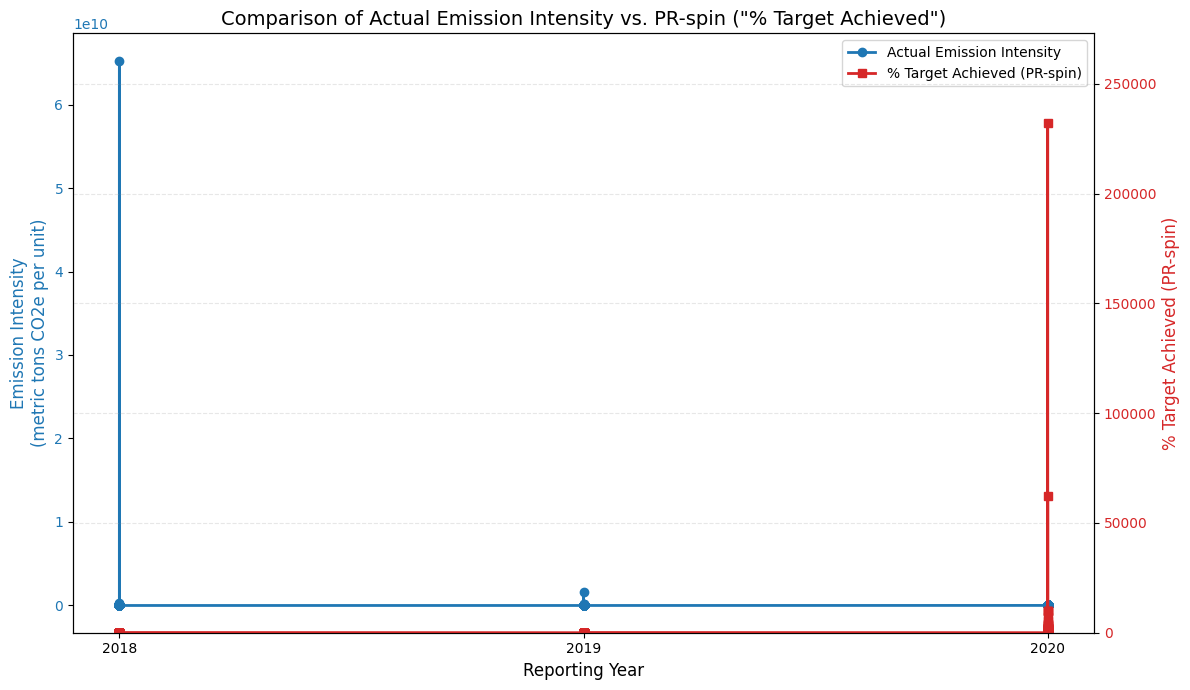

In [22]:
df = (
    metrics
    .select(
        YEAR_COLUMN,
        ACCOUNT_NUMBER_COLUMN,
        INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY,
        INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN
    )
    .filter(
        pl.col(INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY).is_not_null() &
        pl.col(INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN).is_not_null()
    )
    .explode(INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY, INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN)
    .filter(
        ~pl.col(INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY).str.to_lowercase().is_in(['question not applicable', 'hidden answer']) &
        ~pl.col(INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN).str.to_lowercase().is_in(['question not applicable', 'hidden answer'])
    )
    .with_columns(
        pl.col(INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY).cast(pl.Float64, strict=True),
        pl.col(INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN).cast(pl.Float64, strict=True)
    )
)

display(df)

fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot emission intensity on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Reporting Year', fontsize=12)
ax1.set_ylabel('Emission Intensity\n(metric tons CO2e per unit)', color=color, fontsize=12)
ax1.plot(df[YEAR_COLUMN], df[INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY], 'o-', color=color, linewidth=2, 
         label='Actual Emission Intensity')
ax1.tick_params(axis='y', labelcolor=color)

# Create second y-axis for target achieved percentage
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('% Target Achieved (PR-spin)', color=color, fontsize=12)
ax2.plot(df[YEAR_COLUMN], df[INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN], 's-', color=color, linewidth=2,
         label='% Target Achieved (PR-spin)')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(bottom=0)  # Start at 0% for better visualization

# Add title
plt.title('Comparison of Actual Emission Intensity vs. PR-spin ("% Target Achieved")', fontsize=14)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=10)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.3)

# Ensure year ticks are integers
ax1.set_xticks(df[YEAR_COLUMN].unique())
ax1.set_xticklabels([str(int(year)) for year in df[YEAR_COLUMN].unique()])

plt.tight_layout()
plt.show()

/var/folders/tg/hyd2rhps0js2mqd1qr1swd340000gn/T/ipykernel_80553/2520795823.py:35: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias('count')


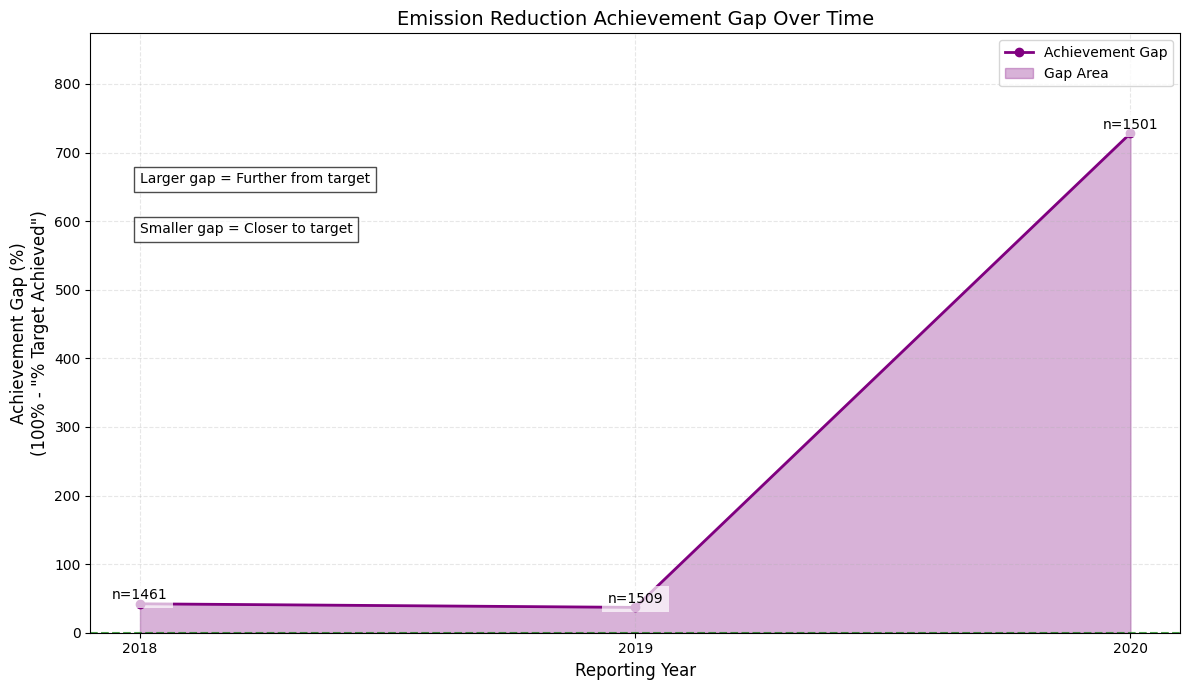

In [23]:
# Use the same dataframe preparation as your code
df = (
    metrics
    .select(
        YEAR_COLUMN,
        ACCOUNT_NUMBER_COLUMN,
        INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY,
        INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN
    )
    .filter(
        pl.col(INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY).is_not_null() &
        pl.col(INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN).is_not_null()
    )
    .explode(INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY, INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN)
    .filter(
        ~pl.col(INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY).str.to_lowercase().is_in(['question not applicable', 'hidden answer']) &
        ~pl.col(INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN).str.to_lowercase().is_in(['question not applicable', 'hidden answer'])
    )
    .with_columns(
        pl.col(INTENSITY_TARGET_FIGURE_COLUMN_PER_ACTIVITY).cast(pl.Float64, strict=True),
        pl.col(INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN).cast(pl.Float64, strict=True)
    )
)

# Calculate the achievement gap (100% - % target achieved)
df = df.with_columns(
    (100 - pl.col(INTENSITY_TARGET_PERCENT_ACHIEVED_COLUMN)).alias('achievement_gap')
)

# Group by year to calculate averages for the gap trend
yearly_gap = (
    df.group_by(YEAR_COLUMN)
    .agg([
        pl.col('achievement_gap').mean().alias('avg_achievement_gap'),
        pl.count().alias('count')
    ])
    .sort(YEAR_COLUMN)
)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the achievement gap over time
ax.plot(yearly_gap[YEAR_COLUMN], yearly_gap['avg_achievement_gap'], 'o-', color='purple', linewidth=2,
        label='Achievement Gap')

# Add data points with count labels
for i, year in enumerate(yearly_gap[YEAR_COLUMN]):
    ax.text(year, yearly_gap['avg_achievement_gap'][i] + 2, 
            f'n={yearly_gap["count"][i]}', 
            ha='center', va='bottom', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Add shaded region to emphasize gap
ax.fill_between(yearly_gap[YEAR_COLUMN], 0, yearly_gap['avg_achievement_gap'], 
                alpha=0.3, color='purple', label='Gap Area')

# Set labels and title
ax.set_xlabel('Reporting Year', fontsize=12)
ax.set_ylabel('Achievement Gap (%)\n(100% - "% Target Achieved")', fontsize=12)
ax.set_title('Emission Reduction Achievement Gap Over Time', fontsize=14)

# Ensure y-axis starts at 0 and has a reasonable upper limit
ax.set_ylim(bottom=0, top=max(yearly_gap['avg_achievement_gap']) * 1.2)

# Ensure year ticks are integers
ax.set_xticks(yearly_gap[YEAR_COLUMN])
ax.set_xticklabels([str(int(year)) for year in yearly_gap[YEAR_COLUMN]])

# Add grid and legend
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='best', fontsize=10)

# Add a horizontal line at 0% gap (100% achievement)
ax.axhline(y=0, color='green', linestyle='--', alpha=0.7, label='Complete Achievement')

# Add annotations to explain the meaning
ax.text(yearly_gap[YEAR_COLUMN].min(), max(yearly_gap['avg_achievement_gap']) * 0.9,
        "Larger gap = Further from target", fontsize=10, 
        bbox=dict(facecolor='white', alpha=0.7))
ax.text(yearly_gap[YEAR_COLUMN].min(), max(yearly_gap['avg_achievement_gap']) * 0.8,
        "Smaller gap = Closer to target", fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

/var/folders/tg/hyd2rhps0js2mqd1qr1swd340000gn/T/ipykernel_80553/3851744011.py:34: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias('count')


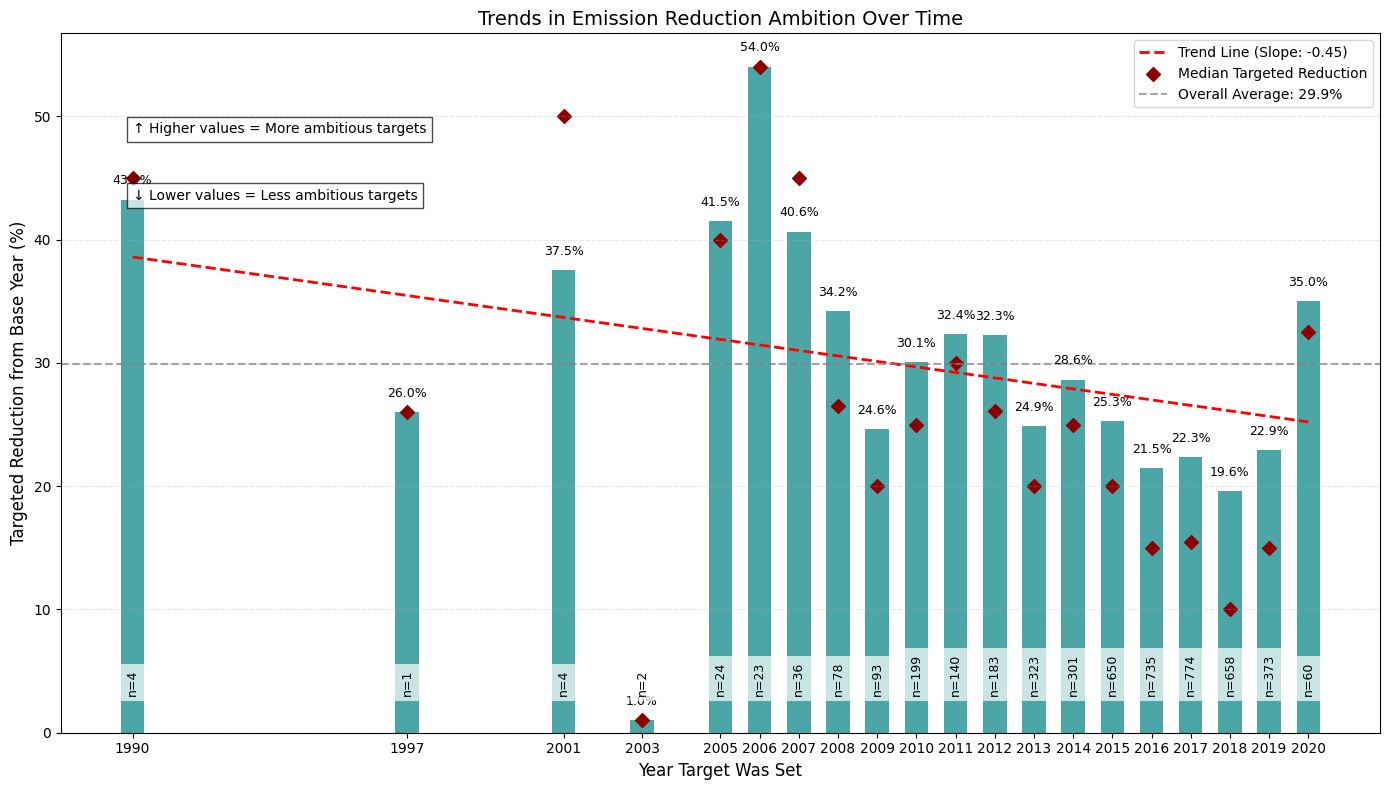

In [ ]:
# Using the dataframe preparation as provided
df = (
    metrics
    .select(
        YEAR_COLUMN,
        ACCOUNT_NUMBER_COLUMN,
        TARGETED_REDUCTION_COLUMN,
        YEAR_TARGET_SET_COLUMN
    )
    .filter(
        pl.col(TARGETED_REDUCTION_COLUMN).is_not_null() &
        pl.col(YEAR_TARGET_SET_COLUMN).is_not_null()
    )
    .explode(TARGETED_REDUCTION_COLUMN, YEAR_TARGET_SET_COLUMN)
    .filter(
        ~pl.col(TARGETED_REDUCTION_COLUMN).str.to_lowercase().is_in(['question not applicable', 'hidden answer']) &
        ~pl.col(YEAR_TARGET_SET_COLUMN).str.to_lowercase().is_in(['question not applicable', 'hidden answer'])
    )
    .with_columns(
        pl.col(TARGETED_REDUCTION_COLUMN).cast(pl.Float64, strict=True),
        pl.col(YEAR_TARGET_SET_COLUMN).cast(pl.Float64, strict=True)
    )
)

# Group by the year the target was set to analyze ambition trends
yearly_ambition = (
    df.group_by(YEAR_TARGET_SET_COLUMN)
    .agg([
        pl.col(TARGETED_REDUCTION_COLUMN).mean().alias('avg_targeted_reduction'),
        pl.col(TARGETED_REDUCTION_COLUMN).median().alias('median_targeted_reduction'),
        pl.count().alias('count')
    ])
    .sort(YEAR_TARGET_SET_COLUMN)
)

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Bar chart for the average targeted reduction
bars = ax.bar(yearly_ambition[YEAR_TARGET_SET_COLUMN], yearly_ambition['avg_targeted_reduction'], 
              color='teal', alpha=0.7, width=0.6)

# Add a trend line to highlight the pattern
x = yearly_ambition[YEAR_TARGET_SET_COLUMN]
y = yearly_ambition['avg_targeted_reduction']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(x, p(x), "r--", linewidth=2, label=f'Trend Line (Slope: {z[0]:.2f})')

# Add data labels showing the average reduction percentage
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{yearly_ambition["avg_targeted_reduction"][i]:.1f}%',
            ha='center', va='bottom', fontsize=9)

# Add sample size annotations
for i, year in enumerate(yearly_ambition[YEAR_TARGET_SET_COLUMN]):
    ax.text(year, 3, f'n={yearly_ambition["count"][i]}', 
            ha='center', va='bottom', fontsize=9, rotation=90,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Add median markers
ax.scatter(yearly_ambition[YEAR_TARGET_SET_COLUMN], yearly_ambition['median_targeted_reduction'], 
           color='darkred', marker='D', s=50, label='Median Targeted Reduction')

# Set labels and title
ax.set_xlabel('Year Target Was Set', fontsize=12)
ax.set_ylabel('Targeted Reduction from Base Year (%)', fontsize=12)
ax.set_title('Trends in Emission Reduction Ambition Over Time', fontsize=14)

# Adjust y-axis to start from 0
ax.set_ylim(bottom=0)

# Ensure x-axis shows all years as integers
ax.set_xticks(yearly_ambition[YEAR_TARGET_SET_COLUMN])
ax.set_xticklabels([str(int(year)) for year in yearly_ambition[YEAR_TARGET_SET_COLUMN]])

# Add a horizontal reference line showing the average ambition across all years
overall_avg = yearly_ambition['avg_targeted_reduction'].mean()
ax.axhline(y=overall_avg, color='gray', linestyle='--', alpha=0.7, 
           label=f'Overall Average: {overall_avg:.1f}%')

# Add annotations explaining the interpretation
higher_text = "↑ Higher values = More ambitious targets"
lower_text = "↓ Lower values = Less ambitious targets"
ax.text(yearly_ambition[YEAR_TARGET_SET_COLUMN].min(), yearly_ambition['avg_targeted_reduction'].max() * 0.9,
        higher_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
ax.text(yearly_ambition[YEAR_TARGET_SET_COLUMN].min(), yearly_ambition['avg_targeted_reduction'].max() * 0.8,
        lower_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

# Add grid and legend
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

#### E. Intensity vs. Time

In [ ]:
ABSOLUTE_TARGETED_REDUCTION_COLUMN = 

# Using the dataframe preparation as provided
df = (
    metrics
    .select(
        YEAR_COLUMN,
        ACCOUNT_NUMBER_COLUMN,
        TARGETED_REDUCTION_COLUMN,
        YEAR_TARGET_SET_COLUMN
    )
    .filter(
        pl.col(TARGETED_REDUCTION_COLUMN).is_not_null() &
        pl.col(YEAR_TARGET_SET_COLUMN).is_not_null()
    )
    .explode(TARGETED_REDUCTION_COLUMN, YEAR_TARGET_SET_COLUMN)
    .filter(
        ~pl.col(TARGETED_REDUCTION_COLUMN).str.to_lowercase().is_in(['question not applicable', 'hidden answer']) &
        ~pl.col(YEAR_TARGET_SET_COLUMN).str.to_lowercase().is_in(['question not applicable', 'hidden answer'])
    )
    .with_columns(
        pl.col(TARGETED_REDUCTION_COLUMN).cast(pl.Float64, strict=True),
        pl.col(YEAR_TARGET_SET_COLUMN).cast(pl.Float64, strict=True)
    )
)

# Group by the year the target was set to analyze ambition trends
yearly_ambition = (
    df.group_by(YEAR_TARGET_SET_COLUMN)
    .agg([
        pl.col(TARGETED_REDUCTION_COLUMN).mean().alias('avg_targeted_reduction'),
        pl.col(TARGETED_REDUCTION_COLUMN).median().alias('median_targeted_reduction'),
        pl.count().alias('count')
    ])
    .sort(YEAR_TARGET_SET_COLUMN)
)

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Bar chart for the average targeted reduction
bars = ax.bar(yearly_ambition[YEAR_TARGET_SET_COLUMN], yearly_ambition['avg_targeted_reduction'], 
              color='teal', alpha=0.7, width=0.6)

# Add a trend line to highlight the pattern
x = yearly_ambition[YEAR_TARGET_SET_COLUMN]
y = yearly_ambition['avg_targeted_reduction']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(x, p(x), "r--", linewidth=2, label=f'Trend Line (Slope: {z[0]:.2f})')

# Add data labels showing the average reduction percentage
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{yearly_ambition["avg_targeted_reduction"][i]:.1f}%',
            ha='center', va='bottom', fontsize=9)

# Add sample size annotations
for i, year in enumerate(yearly_ambition[YEAR_TARGET_SET_COLUMN]):
    ax.text(year, 3, f'n={yearly_ambition["count"][i]}', 
            ha='center', va='bottom', fontsize=9, rotation=90,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Add median markers
ax.scatter(yearly_ambition[YEAR_TARGET_SET_COLUMN], yearly_ambition['median_targeted_reduction'], 
           color='darkred', marker='D', s=50, label='Median Targeted Reduction')

# Set labels and title
ax.set_xlabel('Year Target Was Set', fontsize=12)
ax.set_ylabel('Targeted Reduction from Base Year (%)', fontsize=12)
ax.set_title('Trends in Emission Reduction Ambition Over Time', fontsize=14)

# Adjust y-axis to start from 0
ax.set_ylim(bottom=0)

# Ensure x-axis shows all years as integers
ax.set_xticks(yearly_ambition[YEAR_TARGET_SET_COLUMN])
ax.set_xticklabels([str(int(year)) for year in yearly_ambition[YEAR_TARGET_SET_COLUMN]])

# Add a horizontal reference line showing the average ambition across all years
overall_avg = yearly_ambition['avg_targeted_reduction'].mean()
ax.axhline(y=overall_avg, color='gray', linestyle='--', alpha=0.7, 
           label=f'Overall Average: {overall_avg:.1f}%')

# Add annotations explaining the interpretation
higher_text = "↑ Higher values = More ambitious targets"
lower_text = "↓ Lower values = Less ambitious targets"
ax.text(yearly_ambition[YEAR_TARGET_SET_COLUMN].min(), yearly_ambition['avg_targeted_reduction'].max() * 0.9,
        higher_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
ax.text(yearly_ambition[YEAR_TARGET_SET_COLUMN].min(), yearly_ambition['avg_targeted_reduction'].max() * 0.8,
        lower_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

# Add grid and legend
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

#### F. Deep Analysis

##### I. New

In [ ]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple, Optional
import re

def extract_classification(df: pl.DataFrame, question: str, model: str, label_type: str = "label") -> List:
    """
    Extract classification results for a specific question and model.
    
    Parameters:
    -----------
    df : pl.DataFrame
        The input dataframe containing the classification results
    question : str
        The question column (e.g., "column=1.2. What is the mechanism...|sheet=Governance|value=response")
    model : str
        The model to extract (e.g., "climate_specificity")
    label_type : str
        Either "label" to get classifications or a specific label to get score
        
    Returns:
    --------
    List
        A list containing the extracted classification results as single values (not lists)
    """
    if label_type == "label":
        column_name = f"{question}|model={model}|value=label"
    else:
        column_name = f"{question}|model={model}|label={label_type}|value=score"
    
    # Check if column exists
    if column_name not in df.columns:
        return [None] * len(df)
    
    # Get the column
    col = df[column_name]
    
    # Handle the case where field is a list of responses or None
    results = []
    for field in col:
        if field is None:
            results.append(None)
        else:
            try:
                # Handle different types of nested structures
                if isinstance(field, list):
                    # Take the first non-None response
                    non_none_responses = [r for r in field if r is not None]
                    if non_none_responses:
                        first_val = non_none_responses[0]
                        # Handle potential nested lists
                        if isinstance(first_val, list):
                            nested_val = first_val[0] if first_val else None
                            results.append(nested_val)
                        else:
                            results.append(first_val)
                    else:
                        results.append(None)
                else:
                    # If it's already a single value
                    results.append(field)
            except Exception as e:
                # If any error occurs, return None for this item
                print(f"Error extracting classification for {column_name}: {e}")
                results.append(None)
    
    return results

def calculate_rhetoric_score(df: pl.DataFrame, questions: List[str]) -> List[float]:
    """
    Calculate a rhetoric score based on environmental claims, positive sentiment, 
    and vague commitments.
    """
    # Initialize scores and question counts
    rhetoric_scores = [0.0] * len(df)
    question_counts = [0] * len(df)
    
    # Keep track of contributions to the score for debugging
    contributions = {
        "environmental_claims": [0] * len(df),
        "opportunity_sentiment": [0] * len(df),
        "vague_commitments": [0] * len(df)
    }
    
    for question in questions:
        # Add points for environmental claims
        claims = extract_classification(df, question, "environmental_claims", "label")
        for i, claim in enumerate(claims):
            if claim is not None:
                question_counts[i] += 1
                if claim == "yes":
                    rhetoric_scores[i] += 1.0
                    contributions["environmental_claims"][i] += 1
        
        # Add points for opportunity sentiment
        sentiment = extract_classification(df, question, "climate_sentiment", "label")
        for i, sent in enumerate(sentiment):
            if sent is not None:
                question_counts[i] += 1
                if sent == "opportunity":
                    rhetoric_scores[i] += 1.0
                    contributions["opportunity_sentiment"][i] += 1
        
        # Add points for vague commitments (commitment without specificity)
        commitment = extract_classification(df, question, "climate_commitment", "label")
        specificity = extract_classification(df, question, "climate_specificity", "label")
        
        for i, (commit, spec) in enumerate(zip(commitment, specificity)):
            if commit is not None and spec is not None:
                question_counts[i] += 1
                if commit == "yes" and spec == "non":
                    rhetoric_scores[i] += 1.0
                    contributions["vague_commitments"][i] += 1
    
    # Print contribution statistics for debugging
    total_env_claims = sum(1 for x in contributions["environmental_claims"] if x > 0)
    total_opp_sentiment = sum(1 for x in contributions["opportunity_sentiment"] if x > 0)
    total_vague_commits = sum(1 for x in contributions["vague_commitments"] if x > 0)
    
    print(f"Rhetoric score contributions:")
    print(f"  - Environmental claims: {total_env_claims} companies")
    print(f"  - Opportunity sentiment: {total_opp_sentiment} companies")
    print(f"  - Vague commitments: {total_vague_commits} companies")
    
    # Normalize by the number of non-None questions, but only if there are any
    for i in range(len(rhetoric_scores)):
        if question_counts[i] > 0:
            rhetoric_scores[i] /= question_counts[i]
    
    return rhetoric_scores

def calculate_action_score(df: pl.DataFrame, questions: List[str]) -> List[float]:
    """
    Calculate an action score based on net-zero targets, renewable energy,
    specificity, and transition plans.
    """
    # Initialize scores and question counts
    action_scores = [0.0] * len(df)
    question_counts = [0] * len(df)
    
    # Keep track of contributions to the score for debugging
    contributions = {
        "netzero_reduction": [0] * len(df),
        "renewable": [0] * len(df),
        "specificity": [0] * len(df),
        "transition": [0] * len(df)
    }
    
    for question in questions:
        # Add points for net-zero/reduction targets
        netzero = extract_classification(df, question, "netzero_reduction", "label")
        for i, nz in enumerate(netzero):
            if nz is not None:
                question_counts[i] += 1
                if nz == "net-zero":
                    action_scores[i] += 2.0  # Extra point for net-zero
                    contributions["netzero_reduction"][i] += 2
                elif nz == "reduction":
                    action_scores[i] += 1.0
                    contributions["netzero_reduction"][i] += 1
        
        # Add points for renewable energy
        renewable = extract_classification(df, question, "renewable", "label")
        for i, ren in enumerate(renewable):
            if ren is not None:
                question_counts[i] += 1
                if ren == "LABEL_1":
                    action_scores[i] += 1.0
                    contributions["renewable"][i] += 1
        
        # Add points for specificity
        specificity = extract_classification(df, question, "climate_specificity", "label")
        for i, spec in enumerate(specificity):
            if spec is not None:
                question_counts[i] += 1
                if spec == "spec":
                    action_scores[i] += 1.0
                    contributions["specificity"][i] += 1
        
        # Add points for transition plans
        transition = extract_classification(df, question, "transition", "label")
        for i, trans in enumerate(transition):
            if trans is not None:
                question_counts[i] += 1
                if trans == "LABEL_1":
                    action_scores[i] += 1.0
                    contributions["transition"][i] += 1
    
    # Print contribution statistics for debugging
    total_netzero = sum(1 for x in contributions["netzero_reduction"] if x > 0)
    total_renewable = sum(1 for x in contributions["renewable"] if x > 0)
    total_specificity = sum(1 for x in contributions["specificity"] if x > 0)
    total_transition = sum(1 for x in contributions["transition"] if x > 0)
    
    print(f"Action score contributions:")
    print(f"  - Net-zero/reduction targets: {total_netzero} companies")
    print(f"  - Renewable energy: {total_renewable} companies")
    print(f"  - Specific climate plans: {total_specificity} companies")
    print(f"  - Transition plans: {total_transition} companies")
    
    # Normalize by the number of non-None questions, but only if there are any
    for i in range(len(action_scores)):
        if question_counts[i] > 0:
            action_scores[i] /= question_counts[i]
    
    return action_scores

def extract_year(df: pl.DataFrame) -> pl.Series:
    """Extract the year from relevant columns in the dataframe as single integer values."""
    # Find potential year information columns
    year_candidates = [
        "column=year|sheet=*|value=response",
        "column=C0.2_C1_State the start and end date of the year for which you are reporting data. - Start date|sheet=C0.2|value=response"
    ]
    
    # Try to find a suitable column
    year_col = None
    for col in year_candidates:
        if col in df.columns:
            year_col = col
            break
    
    # If no predefined column is found, try to find one with year in the name
    if not year_col:
        for col in df.columns:
            if "year" in col.lower() and "value=response" in col:
                year_col = col
                break
    
    if year_col:
        # Extract year from date string or direct year value
        years = []
        for val in df[year_col]:
            try:
                if val is None:
                    years.append(None)
                elif isinstance(val, list):
                    # Take first non-None value
                    non_none_vals = [v for v in val if v is not None]
                    if non_none_vals:
                        first_val = non_none_vals[0]
                        # Handle potential nested list
                        if isinstance(first_val, list):
                            nested_val = first_val[0] if first_val else None
                            if nested_val:
                                year_str = str(nested_val)
                                match = re.search(r'20\d\d', year_str)
                                years.append(int(match.group(0)) if match else None)
                            else:
                                years.append(None)
                        else:
                            year_str = str(first_val)
                            match = re.search(r'20\d\d', year_str)
                            years.append(int(match.group(0)) if match else None)
                    else:
                        years.append(None)
                else:
                    year_str = str(val)
                    match = re.search(r'20\d\d', year_str)
                    years.append(int(match.group(0)) if match else None)
            except Exception as e:
                print(f"Error extracting year: {e}")
                years.append(None)
        
        return pl.Series(years)
    
    # If we can't find a year column, look for rows that might have the year in a row ID or similar
    try:
        # Check if there's a row name or ID that might contain the year
        for col in df.columns:
            if "id" in col.lower() or "name" in col.lower():
                years = []
                for val in df[col]:
                    if val is None:
                        years.append(None)
                    else:
                        val_str = str(val)
                        match = re.search(r'20\d\d', val_str)
                        years.append(int(match.group(0)) if match else None)
                
                # If we found at least 1000 valid years, use this column
                if sum(1 for y in years if y is not None) > 1000:
                    return pl.Series(years)
    except Exception:
        pass
    
    # Default to None if no year info found
    return pl.Series([None] * len(df))

def extract_sector(df: pl.DataFrame) -> pl.Series:
    """Extract the sector from relevant columns in the dataframe.
    Returns a single string value for each row, not a list."""
    sector_cols = [
        "column=Primary sector|sheet=Summary Data|value=response",
        "column=Primary industry|sheet=Summary Data|value=response",
        "column=sector|sheet=*|value=response"
    ]
    
    for col in sector_cols:
        if col in df.columns:
            # Extract sector with handling for list values
            sectors = []
            for val in df[col]:
                if val is None:
                    sectors.append(None)
                elif isinstance(val, list):
                    # Take first non-None value
                    non_none_vals = [v for v in val if v is not None]
                    # Further handle the case where the value itself might be a list
                    if non_none_vals:
                        first_val = non_none_vals[0]
                        if isinstance(first_val, list):
                            flat_val = first_val[0] if first_val else None
                            sectors.append(flat_val)
                        else:
                            sectors.append(first_val)
                    else:
                        sectors.append(None)
                else:
                    sectors.append(val)
            
            # Convert any remaining lists to strings
            cleaned_sectors = []
            for s in sectors:
                if isinstance(s, list):
                    cleaned_sectors.append(str(s[0]) if s else None)
                else:
                    cleaned_sectors.append(str(s) if s is not None else None)
            
            return pl.Series(cleaned_sectors)
    
    # Default to None if no sector info found
    return pl.Series([None] * len(df))

def extract_region(df: pl.DataFrame) -> pl.Series:
    """Extract the region/country from relevant columns in the dataframe as single string values."""
    region_cols = [
        "column=Region|sheet=Summary Data|value=response",
        "column=Country|sheet=Summary Data|value=response",
        "column=C0.3_Select the countries/areas for which you will be supplying data.|sheet=C0 - Introduction|value=response"
    ]
    
    for col in region_cols:
        if col in df.columns:
            # Extract region with handling for list values
            regions = []
            for val in df[col]:
                try:
                    if val is None:
                        regions.append(None)
                    elif isinstance(val, list):
                        # Take first non-None value
                        non_none_vals = [v for v in val if v is not None]
                        if non_none_vals:
                            first_val = non_none_vals[0]
                            # Handle potential nested list
                            if isinstance(first_val, list):
                                nested_val = first_val[0] if first_val else None
                                regions.append(str(nested_val) if nested_val is not None else None)
                            else:
                                regions.append(str(first_val))
                        else:
                            regions.append(None)
                    else:
                        regions.append(str(val))
                except Exception as e:
                    print(f"Error extracting region: {e}")
                    regions.append(None)
            
            return pl.Series(regions)
    
    # Default to None if no region info found
    return pl.Series([None] * len(df))

def analyze_greenwashing_gap(metrics: pl.DataFrame) -> Dict:
    """
    Analyze the greenwashing gap over time, by sector, and by region.
    
    Parameters:
    -----------
    metrics : pl.DataFrame
        The input dataframe containing CDP responses and classifications
        
    Returns:
    --------
    Dict
        A dictionary containing the analysis results
    """
    # Print initial data diagnostics
    print(f"Original dataframe has {len(metrics)} rows and {len(metrics.columns)} columns")
    
    # Select key climate and emissions questions - focus on governance, strategy, targets
    rhetoric_questions = [
        "column=C0.1_Give a general description and introduction to your organization.|sheet=C0 - Introduction|value=response",
        "column=C1.1_Is there board-level oversight of climate-related issues within your organization?|sheet=C1 - Governance|value=response",
        "column=C2.4_Have you identified any climate-related opportunities with the potential to have a substantive financial or strategic impact on your business?|sheet=C2 - Risks and Opportunities|value=response",
        "column=9.1. Please describe how your overall group business strategy links with actions taken on risks and opportunities (identified in questions 3 to 8), including any emissions reduction targets or achievements, public policy engagement and external communications.|sheet=Strategy 9|value=response"
    ]
    
    # Filter rhetoric questions to those that actually exist in the dataframe
    rhetoric_questions = [q for q in rhetoric_questions if q in metrics.columns]
    
    action_questions = [
        "column=C4.1_Did you have an emissions target that was active in the reporting year?|sheet=C4 - Targets and Performance|value=response",
        "column=C4.2_Did you have any other climate-related targets that were active in the reporting year?|sheet=C4 - Targets and Performance|value=response",
        "column=C4.3_Did you have emissions reduction initiatives that were active within the reporting year?|sheet=C4 - Targets and Performance|value=response",
        "column=C6.1_C1_What were your organization's gross global Scope 1 emissions in metric tons CO2e? - Gross global Scope 1 emissions (metric tons CO2e)|sheet=C6.1|value=response",
        "column=C7.9_How do your gross global emissions (Scope 1 and 2 combined) for the reporting year compare to those of the previous reporting year?|sheet=C7 - Emissions Breakdown|value=response"
    ]
    
    # Filter action questions to those that actually exist in the dataframe
    action_questions = [q for q in action_questions if q in metrics.columns]
    
    print(f"Found {len(rhetoric_questions)} rhetoric questions and {len(action_questions)} action questions")
    
    # Extract metadata
    years = extract_year(metrics)
    sectors = extract_sector(metrics)
    regions = extract_region(metrics)
    
    print(f"Extracted years, sectors, and regions. Non-null counts: years={sum(1 for y in years if y is not None)}, sectors={sum(1 for s in sectors if s is not None)}, regions={sum(1 for r in regions if r is not None)}")
    
    # Calculate scores
    rhetoric_scores = calculate_rhetoric_score(metrics, rhetoric_questions)
    action_scores = calculate_action_score(metrics, action_questions)
    
    print(f"Calculated rhetoric and action scores for {len(rhetoric_scores)} companies")
    
    # Calculate greenwashing gap
    greenwashing_gap = [r - a for r, a in zip(rhetoric_scores, action_scores)]
    
    # Create a results dataframe with metadata and scores
    results_df = pl.DataFrame({
        "year": years,
        "sector": sectors,
        "region": regions,
        "rhetoric_score": rhetoric_scores,
        "action_score": action_scores,
        "greenwashing_gap": greenwashing_gap
    })
    
    # Filter out rows with missing years
    valid_results = results_df.filter(pl.col("year").is_not_null())
    print(f"After filtering out missing years, have {len(valid_results)} valid results")
    
    # Analyze trends over time
    try:
        time_trends = (
            valid_results
            .group_by("year")
            .agg([
                pl.mean("rhetoric_score").alias("avg_rhetoric"),
                pl.mean("action_score").alias("avg_action"),
                pl.mean("greenwashing_gap").alias("avg_gap"),
                pl.count().alias("count")
            ])
            .sort("year")
        )
        print(f"Generated time trends for {len(time_trends)} years")
    except Exception as e:
        print(f"Error calculating time trends: {e}")
        time_trends = pl.DataFrame({
            "year": [],
            "avg_rhetoric": [],
            "avg_action": [],
            "avg_gap": [],
            "count": []
        })
    
    # Analyze differences by sector - more cautious approach to handle potential list values
    try:
        # Get valid sectors (non-null strings)
        valid_sectors = valid_results.filter(
            (pl.col("sector").is_not_null()) & 
            (~pl.col("sector").str.contains("None"))
        )
        
        # Count by sector
        sector_counts = valid_sectors.group_by("sector").agg(pl.count().alias("count"))
        
        # Get top sectors (at least 50 records)
        top_sectors = sector_counts.filter(pl.col("count") >= 50)
        top_sector_names = top_sectors["sector"].to_list()
        
        print(f"Found {len(top_sector_names)} top sectors with at least 50 records each")
        
        # Manual filtering approach to avoid is_in with lists
        sector_rows = []
        for sector in top_sector_names:
            sector_data = valid_sectors.filter(pl.col("sector") == sector)
            if len(sector_data) > 0:
                avg_rhetoric = sector_data["rhetoric_score"].mean()
                avg_action = sector_data["action_score"].mean()
                avg_gap = sector_data["greenwashing_gap"].mean()
                count = len(sector_data)
                sector_rows.append({
                    "sector": sector,
                    "avg_rhetoric": avg_rhetoric,
                    "avg_action": avg_action,
                    "avg_gap": avg_gap,
                    "count": count
                })
        
        sector_differences = pl.DataFrame(sector_rows).sort("avg_gap", descending=True)
        print(f"Generated sector differences for {len(sector_differences)} sectors")
    except Exception as e:
        print(f"Error calculating sector differences: {e}")
        sector_differences = pl.DataFrame({
            "sector": [],
            "avg_rhetoric": [],
            "avg_action": [],
            "avg_gap": [],
            "count": []
        })
    
    # Analyze differences by region - similar cautious approach
    try:
        # Get valid regions (non-null strings)
        valid_regions = valid_results.filter(
            (pl.col("region").is_not_null()) & 
            (~pl.col("region").str.contains("None"))
        )
        
        # Count by region
        region_counts = valid_regions.group_by("region").agg(pl.count().alias("count"))
        
        # Get top regions (at least 50 records)
        top_regions = region_counts.filter(pl.col("count") >= 50)
        top_region_names = top_regions["region"].to_list()
        
        print(f"Found {len(top_region_names)} top regions with at least 50 records each")
        
        # Manual filtering approach
        region_rows = []
        for region in top_region_names:
            region_data = valid_regions.filter(pl.col("region") == region)
            if len(region_data) > 0:
                avg_rhetoric = region_data["rhetoric_score"].mean()
                avg_action = region_data["action_score"].mean()
                avg_gap = region_data["greenwashing_gap"].mean()
                count = len(region_data)
                region_rows.append({
                    "region": region,
                    "avg_rhetoric": avg_rhetoric,
                    "avg_action": avg_action,
                    "avg_gap": avg_gap,
                    "count": count
                })
        
        region_differences = pl.DataFrame(region_rows).sort("avg_gap", descending=True)
        print(f"Generated region differences for {len(region_differences)} regions")
    except Exception as e:
        print(f"Error calculating region differences: {e}")
        region_differences = pl.DataFrame({
            "region": [],
            "avg_rhetoric": [],
            "avg_action": [],
            "avg_gap": [],
            "count": []
        })
    
    # Analyze impact of Paris Agreement (2015)
    try:
        pre_paris = (
            valid_results
            .filter(pl.col("year") < 2015)
            .agg([
                pl.mean("rhetoric_score").alias("avg_rhetoric"),
                pl.mean("action_score").alias("avg_action"),
                pl.mean("greenwashing_gap").alias("avg_gap"),
                pl.count().alias("count")
            ])
        )
        
        post_paris = (
            valid_results
            .filter(pl.col("year") >= 2015)
            .agg([
                pl.mean("rhetoric_score").alias("avg_rhetoric"),
                pl.mean("action_score").alias("avg_action"),
                pl.mean("greenwashing_gap").alias("avg_gap"),
                pl.count().alias("count")
            ])
        )
        
        print(f"Calculated Paris Agreement impact: pre-Paris n={pre_paris['count'][0]}, post-Paris n={post_paris['count'][0]}")
    except Exception as e:
        print(f"Error calculating Paris Agreement impact: {e}")
        pre_paris = pl.DataFrame({"avg_rhetoric": [None], "avg_action": [None], "avg_gap": [None], "count": [0]})
        post_paris = pl.DataFrame({"avg_rhetoric": [None], "avg_action": [None], "avg_gap": [None], "count": [0]})
    
    # Look at the change in gap after Paris Agreement by sector
    try:
        # For each top sector, calculate pre and post Paris metrics
        paris_sector_rows = []
        for sector in top_sector_names:
            # Pre-Paris
            pre_sector = valid_results.filter((pl.col("sector") == sector) & (pl.col("year") < 2015))
            if len(pre_sector) > 10:  # Require at least 10 records
                pre_gap = pre_sector["greenwashing_gap"].mean()
                pre_count = len(pre_sector)
                
                # Post-Paris
                post_sector = valid_results.filter((pl.col("sector") == sector) & (pl.col("year") >= 2015))
                if len(post_sector) > 10:  # Require at least 10 records
                    post_gap = post_sector["greenwashing_gap"].mean()
                    post_count = len(post_sector)
                    
                    # Add to results
                    paris_sector_rows.append({
                        "sector": sector,
                        "pre_paris_gap": pre_gap,
                        "post_paris_gap": post_gap,
                        "gap_change": post_gap - pre_gap,
                        "pre_count": pre_count,
                        "post_count": post_count
                    })
        
        paris_impact_by_sector_df = pl.DataFrame(paris_sector_rows).sort("gap_change")
        print(f"Generated Paris impact by sector for {len(paris_impact_by_sector_df)} sectors")
    except Exception as e:
        print(f"Error calculating Paris impact by sector: {e}")
        paris_impact_by_sector_df = pl.DataFrame({
            "sector": [],
            "pre_paris_gap": [],
            "post_paris_gap": [],
            "gap_change": [],
            "pre_count": [],
            "post_count": []
        })
    
    return {
        "results_df": valid_results,
        "time_trends": time_trends,
        "sector_differences": sector_differences,
        "region_differences": region_differences,
        "pre_paris": pre_paris,
        "post_paris": post_paris,
        "paris_impact_by_sector": paris_impact_by_sector_df
    }

def visualize_results(results: Dict):
    """
    Create visualizations for the greenwashing gap analysis.
    
    Parameters:
    -----------
    results : Dict
        The analysis results from analyze_greenwashing_gap
    """
    # Convert to pandas for easier plotting
    time_trends = results["time_trends"].to_pandas()
    sector_diff = results["sector_differences"].to_pandas().head(10)  # Top 10 sectors
    region_diff = results["region_differences"].to_pandas().head(10)  # Top 10 regions
    paris_impact = results["paris_impact_by_sector"].to_pandas()
    
    # 1. Time trends plot
    plt.figure(figsize=(12, 6))
    plt.plot(time_trends["year"], time_trends["avg_rhetoric"], 'b-', label="Rhetoric Score")
    plt.plot(time_trends["year"], time_trends["avg_action"], 'g-', label="Action Score")
    plt.plot(time_trends["year"], time_trends["avg_gap"], 'r-', label="Greenwashing Gap")
    plt.axvline(x=2015, color="gray", linestyle="--", label="Paris Agreement")
    plt.xlabel("Year")
    plt.ylabel("Score")
    plt.title("Climate Rhetoric vs. Action Over Time (2010-2020)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Sector differences plot
    plt.figure(figsize=(14, 8))
    sector_colors = ['#FF9999' if x > 0 else '#99FF99' for x in sector_diff["avg_gap"]]
    bars = plt.barh(sector_diff["sector"], sector_diff["avg_gap"], color=sector_colors)
    plt.axvline(x=0, color="gray", linestyle="--")
    plt.xlabel("Greenwashing Gap (Rhetoric - Action)")
    plt.title("Top 10 Sectors by Greenwashing Gap")
    plt.grid(True, axis="x", alpha=0.3)
    
    # 3. Region differences plot
    plt.figure(figsize=(14, 8))
    region_colors = ['#FF9999' if x > 0 else '#99FF99' for x in region_diff["avg_gap"]]
    bars = plt.barh(region_diff["region"], region_diff["avg_gap"], color=region_colors)
    plt.axvline(x=0, color="gray", linestyle="--")
    plt.xlabel("Greenwashing Gap (Rhetoric - Action)")
    plt.title("Top 10 Regions by Greenwashing Gap")
    plt.grid(True, axis="x", alpha=0.3)
    
    # 4. Impact of Paris Agreement by sector
    # Get 5 most improved and 5 most worsened sectors
    improving = paris_impact.sort_values("gap_change").head(5)
    worsening = paris_impact.sort_values("gap_change", ascending=False).head(5)
    combined = pd.concat([improving, worsening])
    
    plt.figure(figsize=(14, 8))
    colors = ['#99FF99' if x < 0 else '#FF9999' for x in combined["gap_change"]]
    bars = plt.barh(combined["sector"], combined["gap_change"], color=colors)
    plt.axvline(x=0, color="gray", linestyle="--")
    plt.xlabel("Change in Greenwashing Gap After Paris Agreement")
    plt.title("Sectors with Most Changed Greenwashing Gap After Paris Agreement")
    plt.grid(True, axis="x", alpha=0.3)
    
    # Additional plot: Rhetoric vs Action scatter by sector
    top_sectors_df = results["sector_differences"].to_pandas()
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(top_sectors_df["avg_rhetoric"], 
                          top_sectors_df["avg_action"],
                          s=top_sectors_df["count"]/10,  # Size by count
                          alpha=0.6)
    
    # Add diagonal line representing equal rhetoric and action
    max_val = max(top_sectors_df["avg_rhetoric"].max(), top_sectors_df["avg_action"].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    
    # Label points
    for i, row in top_sectors_df.iterrows():
        plt.annotate(row["sector"], 
                    (row["avg_rhetoric"], row["avg_action"]),
                    xytext=(5, 5),
                    textcoords="offset points")
    
    plt.xlabel("Rhetoric Score")
    plt.ylabel("Action Score")
    plt.title("Climate Rhetoric vs. Climate Action by Sector")
    plt.grid(True, alpha=0.3)
    
    # Show all plots
    plt.tight_layout()
    plt.show()

# Run the analysis
def main():
    print("Starting Greenwashing Gap Analysis...")
    results = analyze_greenwashing_gap(metrics)
    print("Analysis complete. Generating visualizations...")
    visualize_results(results)
    
    # Print key insights
    print("\nKey Insights:")
    print("-" * 80)
    
    # Time trends
    try:
        time_df = results["time_trends"].to_pandas()
        if len(time_df) > 0:
            start_year = time_df["year"].min()
            end_year = time_df["year"].max()
            start_gap = time_df[time_df["year"] == start_year]["avg_gap"].values[0]
            end_gap = time_df[time_df["year"] == end_year]["avg_gap"].values[0]
            
            print(f"1. From {start_year} to {end_year}, the average greenwashing gap changed from {start_gap:.3f} to {end_gap:.3f}")
        else:
            print("1. No time trend data available")
    except Exception as e:
        print(f"1. Error analyzing time trends: {e}")
    
    # Sectors with highest gap
    try:
        top_sector = results["sector_differences"].head(1).to_pandas()
        if len(top_sector) > 0:
            print(f"2. The sector with the highest greenwashing gap is {top_sector['sector'].values[0]} ({top_sector['avg_gap'].values[0]:.3f})")
        else:
            print("2. No sector data available")
    except Exception as e:
        print(f"2. Error analyzing sectors: {e}")
    
    # Sectors with lowest gap
    try:
        bottom_sector = results["sector_differences"].sort("avg_gap").head(1).to_pandas()
        if len(bottom_sector) > 0:
            print(f"3. The sector with the lowest greenwashing gap is {bottom_sector['sector'].values[0]} ({bottom_sector['avg_gap'].values[0]:.3f})")
        else:
            print("3. No sector data available")
    except Exception as e:
        print(f"3. Error analyzing sectors: {e}")
    
    # Paris Agreement impact
    try:
        pre_paris_gap = results["pre_paris"]["avg_gap"][0]
        post_paris_gap = results["post_paris"]["avg_gap"][0]
        
        if pre_paris_gap is not None and post_paris_gap is not None:
            gap_change = post_paris_gap - pre_paris_gap
            print(f"4. After the Paris Agreement, the average greenwashing gap changed by {gap_change:.3f}")
        else:
            print("4. No Paris Agreement impact data available")
    except Exception as e:
        print(f"4. Error analyzing Paris Agreement impact: {e}")
    
    # Most improved sector after Paris
    try:
        paris_impact = results["paris_impact_by_sector"]
        if len(paris_impact) > 0:
            most_improved = paris_impact.sort("gap_change").head(1).to_pandas()
            print(f"5. The most improved sector after Paris Agreement is {most_improved['sector'].values[0]} (gap decreased by {-most_improved['gap_change'].values[0]:.3f})")
        
            # Most worsened sector after Paris
            most_worsened = paris_impact.sort("gap_change", descending=True).head(1).to_pandas()
            print(f"6. The sector with the largest increase in greenwashing gap after Paris is {most_worsened['sector'].values[0]} (gap increased by {most_worsened['gap_change'].values[0]:.3f})")
        else:
            print("5-6. No Paris Agreement sector impact data available")
    except Exception as e:
        print(f"5-6. Error analyzing Paris Agreement sector impact: {e}")
    
    print("-" * 80)
    print("Analysis complete!")

if __name__ == "__main__":
    main()

##### II. Old

In [ ]:
# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

class CDPClimateAnalyzer:
    """Analyzes CDP climate disclosure data to identify patterns and evolution of corporate climate action."""
    
    def __init__(self, df: pl.DataFrame | None = None):
        """Initialize with a Polars DataFrame containing CDP data."""
        self.df = df
        self.yearly_data = {}  # To store data grouped by year
        self.indicators = []   # List of climate action indicators
        
    def load_data(self) -> None:
        """Preprocess the CDP data."""
        print("Processing CDP disclosure data...")
        
        if self.df is None:
            raise ValueError("No data provided. Please initialize with a valid Polars DataFrame.")
        
        # Define climate action indicators for our analysis with corrected column names (Note: AI-narrowed search, Claude)
        self.indicators = [
            ("has_board_oversight", "Board Oversight", "C1.1_Is there board-level oversight of climate-related issues within your organization? - Governance", "Yes"),
            ("has_strategy_integration", "Strategy Integration", "C3.1_Are climate-related issues integrated into your business strategy? - C3 - Business strategy", "Yes"),
            ("uses_scenario_analysis", "Scenario Analysis", "C3.1a_Does your organization use climate-related scenario analysis to inform its strategy? - C3 - Business Strategy", "Yes"),
            ("has_risk_process", "Risk Process", "C2.1_Does your organization have a process for identifying, assessing, and responding to climate-related risks and opportunities? - C2 - Risks and Opportunities", "Yes"),
            ("identified_climate_risks", "Climate Risks Identified", "C2.3_Have you identified any inherent climate-related risks with the potential to have a substantive financial or strategic impact on your business? - C2 - Risks and Opportunities", "Yes"),
            ("identified_climate_opportunities", "Climate Opportunities Identified", "C2.4_Have you identified any climate-related opportunities with the potential to have a substantive financial or strategic impact on your business? - C2 - Risks and Opportunities", "Yes"),
            ("has_emissions_target", "Emissions Target", "C4.1_Did you have an emissions target that was active in the reporting year? - C4 - Targets and Performance", "Yes"),
            ("has_internal_carbon_price", "Internal Carbon Price", "C11.3_Does your organization use an internal price on carbon? - C11 - Carbon Pricing", "Yes"),
            ("has_reduction_initiatives", "Reduction Initiatives", "C4.3_Did you have emissions reduction initiatives that were active within the reporting year? - C4 - Targets and Performance", "Yes"),
            ("has_low_carbon_products", "Low-Carbon Products", "C4.5_Do you classify any of your existing goods and/or services as low-carbon products or do they enable a third party to avoid GHG emissions? - C4 - Targets and Performance", "Yes"),
            ("engages_value_chain", "Value Chain Engagement", "C12.1_Do you engage with your value chain on climate-related issues? - C12 - Engagement", "Yes"),
            ("engages_policy", "Policy Engagement", "C12.3_Do you engage in activities that could either directly or indirectly influence public policy on climate-related issues through any of the following? - C12 - Engagement", "Yes"),
        ]
        
        print(f"Loaded data with {len(self.df)} rows")
        
        # Create binary indicators for key climate actions
        self._create_binary_indicators()
        
        # Group data by year for easier analysis
        years = self.df["year__*"].unique().sort().to_list()
        for year in years:
            self.yearly_data[year] = self.df.filter(pl.col("year__*") == year)

    def _create_binary_indicators(self) -> None:
        """Create binary indicators for key climate-related actions."""
        # Create a column for each indicator
        for col_name, _, source_col, positive_value in self.indicators:
            self.df = self.df.with_columns(
                pl.when(pl.col(source_col) == positive_value).then(1).otherwise(0).alias(col_name)
            )
        
        # Create additional indicators from label columns
        self.df = self.df.with_columns([
            pl.when(pl.col("__netzero__label") == "net-zero").then(1).otherwise(0).alias("has_netzero_target"),
            pl.when(pl.col("__renewable__label") == "LABEL_1").then(1).otherwise(0).alias("has_renewable_initiative"),
            pl.when(pl.col("__specificity__label") == "spec").then(1).otherwise(0).alias("has_specific_disclosure"),
            pl.when(pl.col("__environmental_claims__label") == "yes").then(1).otherwise(0).alias("makes_environmental_claims")
        ])

        # Create a maturity score as the sum of all binary indicators
        indicator_cols = [col[0] for col in self.indicators] + [
            "has_netzero_target", "has_renewable_initiative", 
            "has_specific_disclosure", "makes_environmental_claims"
        ]
        
        self.df = self.df.with_columns(
            pl.sum_horizontal([pl.col(col) for col in indicator_cols]).alias("climate_maturity_score")
        )
        
    def analyze_adoption_trends(self) -> pl.DataFrame:
        """Analyze the adoption trends of climate actions over time."""
        print("Analyzing adoption trends of climate actions...")
        
        # Indicators to track (name, column)
        indicators = [(display_name, col_name) for col_name, display_name, _, _ in self.indicators]
        indicators += [
            ("Net-Zero Target", "has_netzero_target"),
            ("Renewable Initiative", "has_renewable_initiative"),
            ("Specific Disclosure", "has_specific_disclosure"),
            ("Environmental Claims", "makes_environmental_claims")
        ]
        
        # Calculate adoption rates by year
        yearly_trends = []
        
        for year in sorted(self.yearly_data.keys()):
            year_df = self.yearly_data[year]
            row = {"year": year}
            
            for display_name, col_name in indicators:
                adoption_rate = year_df.select(pl.mean(col_name)).item()
                row[display_name] = adoption_rate
            
            yearly_trends.append(row)
        
        return pl.DataFrame(yearly_trends)
    
    def create_climate_action_network(self, year: int) -> nx.Graph:
        """Create a network visualization of relationships between climate actions."""
        print(f"Creating climate action network for {year}...")
        year_data = self.yearly_data[year]
        
        # Select the binary indicator columns for network analysis
        indicator_cols = [col[0] for col in self.indicators] + [
            "has_netzero_target", "has_renewable_initiative"
        ]
        
        # Create correlation matrix
        # Convert to pandas for correlation calculation since it's easier
        pd_df = year_data.select(indicator_cols).to_pandas()
        corr_matrix = pd_df.corr().values
        
        # Create network graph
        G = nx.Graph()
        
        # Add nodes with proper labels
        node_labels = {}
        for col in indicator_cols:
            # Find display name for indicator
            display_name = next((name for c, name, _, _ in self.indicators if c == col), col)
            if col == "has_netzero_target":
                display_name = "Net-Zero Target"
            elif col == "has_renewable_initiative":
                display_name = "Renewable Initiative"
                
            G.add_node(col, name=display_name)
            node_labels[col] = display_name
        
        # Add edges based on correlation strength
        for i in range(len(indicator_cols)):
            for j in range(i+1, len(indicator_cols)):
                correlation = corr_matrix[i, j]
                if abs(correlation) > 0.2:  # Only add edges for correlations > 0.2
                    G.add_edge(indicator_cols[i], indicator_cols[j], weight=correlation)
        
        return G, node_labels
    
    def perform_network_analysis(self, G: nx.Graph) -> dict:
        """Perform network analysis on the climate action network."""
        print("Performing network analysis...")
        
        results = {}
        
        # Calculate node centrality measures
        results["degree_centrality"] = nx.degree_centrality(G)
        results["betweenness_centrality"] = nx.betweenness_centrality(G)
        results["eigenvector_centrality"] = nx.eigenvector_centrality(G, max_iter=1000)
        
        # Identify communities
        try:
            results["communities"] = list(nx.community.greedy_modularity_communities(G))
        except:
            # Fall back to simpler community detection if the above fails
            results["communities"] = []
        
        # Find most central nodes (influential climate actions)
        central_nodes = sorted(results["eigenvector_centrality"].items(), key=lambda x: x[1], reverse=True)
        results["most_central_actions"] = central_nodes
        
        return results
    
    def perform_maturity_clustering(self, year: int) -> Dict:
        """Perform clustering to identify distinct climate maturity profiles."""
        print(f"Performing maturity clustering for {year}...")
        
        year_data = self.yearly_data[year]
        
        # Feature categories
        governance_indicators = ["has_board_oversight"]
        strategy_indicators = ["has_strategy_integration", "uses_scenario_analysis"]
        risk_mgmt_indicators = ["has_risk_process", "identified_climate_risks", "identified_climate_opportunities"]
        metrics_indicators = ["has_emissions_target", "has_internal_carbon_price", "has_netzero_target"]
        implementation_indicators = ["has_reduction_initiatives", "has_low_carbon_products", "has_renewable_initiative"]
        engagement_indicators = ["engages_value_chain", "engages_policy"]
        
        # Create category scores as percentage of maximum possible
        year_data = year_data.with_columns([
            (pl.sum_horizontal(governance_indicators) / len(governance_indicators) * 100).alias("governance_pct"),
            (pl.sum_horizontal(strategy_indicators) / len(strategy_indicators) * 100).alias("strategy_pct"),
            (pl.sum_horizontal(risk_mgmt_indicators) / len(risk_mgmt_indicators) * 100).alias("risk_mgmt_pct"),
            (pl.sum_horizontal(metrics_indicators) / len(metrics_indicators) * 100).alias("metrics_pct"),
            (pl.sum_horizontal(implementation_indicators) / len(implementation_indicators) * 100).alias("implementation_pct"),
            (pl.sum_horizontal(engagement_indicators) / len(engagement_indicators) * 100).alias("engagement_pct")
        ])
        
        # Features for clustering
        feature_cols = ["governance_pct", "strategy_pct", "risk_mgmt_pct", 
                       "metrics_pct", "implementation_pct", "engagement_pct"]
        
        # Extract feature matrix
        features = year_data.select(feature_cols).to_numpy()
        
        # Standardize features
        scaler = StandardScaler()
        features_std = scaler.fit_transform(features)
        
        # Find optimal number of clusters using silhouette score
        from sklearn.metrics import silhouette_score
        
        silhouette_scores = []
        K_range = range(2, 7)
        
        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(features_std)
            silhouette_avg = silhouette_score(features_std, cluster_labels)
            silhouette_scores.append(silhouette_avg)
        
        # Choose optimal K (you might want to visualize this in practice)
        optimal_k = K_range[np.argmax(silhouette_scores)]
        
        # Apply KMeans with optimal K
        kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(features_std)
        
        # Add cluster labels to the dataframe (convert to list for Polars)
        year_data = year_data.with_columns(
            pl.Series(name="climate_typology_cluster", values=clusters.tolist())
        )
        
        # Calculate cluster profiles
        cluster_profiles = []
        for cluster_id in range(optimal_k):
            cluster_data = year_data.filter(pl.col("climate_typology_cluster") == cluster_id)
            
            profile = {
                "cluster_id": cluster_id,
                "size": len(cluster_data),
                "percentage": len(cluster_data) / len(year_data) * 100
            }
            
            # Calculate average feature values for this cluster
            for col in feature_cols:
                profile[col] = cluster_data[col].mean()
                
            # Calculate average climate maturity score
            profile["avg_maturity_score"] = cluster_data["climate_maturity_score"].mean()
            
            # Identify dominant sectors
            if len(cluster_data) > 0:
                sector_counts = cluster_data.group_by("Primary sector__Summary Data").agg(
                    pl.count().alias("count")
                ).sort("count", reverse=True)
                
                if len(sector_counts) > 0:
                    top_sector = sector_counts[0, "Primary sector__Summary Data"]
                    top_sector_pct = sector_counts[0, "count"] / len(cluster_data) * 100
                    profile["dominant_sector"] = top_sector
                    profile["dominant_sector_pct"] = top_sector_pct
            
            cluster_profiles.append(profile)
        
        # Interpret cluster characteristics
        cluster_names = []
        for profile in cluster_profiles:
            # Look at relative strengths to characterize the cluster
            values = [profile[col] for col in feature_cols]
            max_value = max(values)
            max_index = values.index(max_value)
            min_value = min(values)
            
            # Very basic naming logic - in a real analysis you'd want more sophisticated naming
            if max_value < 30:  # Low across all dimensions
                name = "Climate Beginners"
            elif profile["governance_pct"] > 70 and profile["strategy_pct"] > 70:
                name = "Strategic Leaders"
            elif profile["implementation_pct"] > 70:
                name = "Implementation Focused"
            elif profile["risk_mgmt_pct"] > 70:
                name = "Risk Management Focused"
            elif profile["metrics_pct"] > 70:
                name = "Metrics & Targets Focused"
            else:
                name = f"Cluster {profile['cluster_id']}"
                
            cluster_names.append(name)
        
        return {
            "kmeans": kmeans,
            "clusters": clusters,
            "optimal_k": optimal_k,
            "scaler": scaler,
            "profiles": cluster_profiles,
            "cluster_names": cluster_names,
            "clustered_data": year_data
        }
        
    def analyze_sector_differences(self) -> pl.DataFrame:
        """Analyze differences in climate action adoption by sector."""
        print("Analyzing sector differences...")
        
        # Analyze maturity score and key indicators by sector over time
        sector_analysis = self.df.group_by(["year__*", "Primary sector__Summary Data"]).agg([
            pl.mean("climate_maturity_score").alias("avg_maturity_score"),
            pl.mean("has_board_oversight").alias("avg_board_oversight"),
            pl.mean("has_strategy_integration").alias("avg_strategy_integration"),
            pl.mean("has_emissions_target").alias("avg_emissions_target"),
            pl.mean("has_netzero_target").alias("avg_netzero_target"),
            pl.mean("has_internal_carbon_price").alias("avg_carbon_price"),
            pl.count().alias("company_count")
        ])
        
        return sector_analysis
    
    def analyze_governance_impact(self) -> Dict:
        """Analyze the impact of governance on other climate actions."""
        print("Analyzing governance impact...")
        
        # Use the latest year for this analysis
        latest_year = max(self.yearly_data.keys())
        latest_data = self.yearly_data[latest_year]
        
        # Look at the relationship between board oversight and other actions
        governance_impact = latest_data.group_by("has_board_oversight").agg([
            pl.mean("has_strategy_integration").alias("avg_strategy_integration"),
            pl.mean("has_emissions_target").alias("avg_emissions_target"),
            pl.mean("has_netzero_target").alias("avg_netzero_target"),
            pl.mean("has_internal_carbon_price").alias("avg_carbon_price"),
            pl.mean("has_reduction_initiatives").alias("avg_reduction_initiatives"),
            pl.mean("has_specific_disclosure").alias("avg_specific_disclosure"),
            pl.count().alias("count")
        ])
        
        # Extract impact data
        with_governance = governance_impact.filter(pl.col("has_board_oversight") == 1)
        without_governance = governance_impact.filter(pl.col("has_board_oversight") == 0)
        
        # Calculate percentage differences
        impact = {}
        for col in governance_impact.columns:
            if col.startswith("avg_") and col != "avg_board_oversight":
                with_value = with_governance[0, col]
                without_value = without_governance[0, col]
                
                if without_value > 0:
                    pct_difference = (with_value / without_value - 1) * 100
                    impact[col.replace("avg_", "")] = pct_difference
                else:
                    impact[col.replace("avg_", "")] = float('inf')  # In case of division by zero
        
        return {
            "year": latest_year,
            "raw_data": governance_impact,
            "impact": impact
        }
    
    def analyze_sentiment_trends(self) -> pl.DataFrame:
        """Analyze trends in climate sentiment over time."""
        print("Analyzing sentiment trends...")
        
        sentiment_trend = self.df.group_by("year__*").agg([
            pl.col("__sentiment__label").filter(pl.col("__sentiment__label") == "opportunity").count().alias("opportunity_count"),
            pl.col("__sentiment__label").filter(pl.col("__sentiment__label") == "risk").count().alias("risk_count"),
            pl.col("__sentiment__label").filter(pl.col("__sentiment__label") == "neutral").count().alias("neutral_count"),
            pl.count().alias("total_count")
        ])
        
        sentiment_trend = sentiment_trend.with_columns([
            (pl.col("opportunity_count") / pl.col("total_count") * 100).alias("opportunity_pct"),
            (pl.col("risk_count") / pl.col("total_count") * 100).alias("risk_pct"),
            (pl.col("neutral_count") / pl.col("total_count") * 100).alias("neutral_pct")
        ])
        
        # Calculate opportunity-to-risk ratio
        sentiment_trend = sentiment_trend.with_columns(
            (pl.col("opportunity_pct") / pl.col("risk_pct")).alias("opportunity_risk_ratio")
        )
        
        return sentiment_trend
    
    def analyze_disclosure_quality(self) -> pl.DataFrame:
        """Analyze trends in disclosure quality/specificity over time."""
        print("Analyzing disclosure quality trends...")
        
        quality_trend = self.df.group_by("year__*").agg([
            pl.col("__specificity__label").filter(pl.col("__specificity__label") == "spec").count().alias("specific_count"),
            pl.count().alias("total_count")
        ])
        
        quality_trend = quality_trend.with_columns(
            (pl.col("specific_count") / pl.col("total_count") * 100).alias("specificity_pct")
        )
        
        return quality_trend
        
    def visualize_adoption_trends(self, trends_df: pl.DataFrame) -> None:
        """Visualize the adoption trends of climate actions over time."""
        plt.figure(figsize=(14, 8))
        
        # Select key indicators for visualization
        key_indicators = [
            "Board Oversight", 
            "Strategy Integration", 
            "Emissions Target", 
            "Net-Zero Target",
            "Internal Carbon Price",
            "Reduction Initiatives"
        ]
        
        # Convert to pandas for easier plotting
        pd_df = trends_df.to_pandas().set_index("year")
        
        # Plot the trends
        for indicator in key_indicators:
            plt.plot(pd_df.index, pd_df[indicator] * 100, marker='o', linewidth=2, label=indicator)
        
        plt.title('Adoption of Climate Actions (2010-2020)', fontsize=16)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Adoption Rate (%)', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.xticks(pd_df.index)
        
        # Add annotations for the latest year
        latest_year = pd_df.index[-1]
        for indicator in key_indicators:
            latest_value = pd_df.loc[latest_year, indicator] * 100
            plt.annotate(f'{latest_value:.1f}%', 
                         xy=(latest_year, latest_value),
                         xytext=(5, 0), 
                         textcoords='offset points',
                         fontsize=10)
        
        plt.tight_layout()
        plt.savefig('adoption_trends.png')
        plt.close()
        
    def visualize_network(self, G: nx.Graph, node_labels: Dict, year: int, network_results: Dict) -> None:
        """Visualize the climate action network."""
        plt.figure(figsize=(14, 12))
        
        # Define node categories for coloring
        governance_nodes = ["has_board_oversight"]
        strategy_nodes = ["has_strategy_integration", "uses_scenario_analysis"]
        risk_nodes = ["has_risk_process", "identified_climate_risks", "identified_climate_opportunities"]
        metrics_nodes = ["has_emissions_target", "has_internal_carbon_price", "has_netzero_target"]
        implementation_nodes = ["has_reduction_initiatives", "has_low_carbon_products", "has_renewable_initiative"]
        engagement_nodes = ["engages_value_chain", "engages_policy"]
        
        # Assign colors based on category
        node_colors = []
        for node in G.nodes():
            if node in governance_nodes:
                node_colors.append('tab:red')
            elif node in strategy_nodes:
                node_colors.append('tab:orange')
            elif node in risk_nodes:
                node_colors.append('tab:blue')
            elif node in metrics_nodes:
                node_colors.append('tab:green')
            elif node in implementation_nodes:
                node_colors.append('tab:purple')
            elif node in engagement_nodes:
                node_colors.append('tab:brown')
            else:
                node_colors.append('tab:gray')
        
        # Calculate node sizes based on centrality
        centrality = network_results["eigenvector_centrality"]
        node_sizes = [centrality[node] * 3000 + 300 for node in G.nodes()]
        
        # Calculate edge widths and colors based on correlation strength
        edge_widths = []
        edge_colors = []
        
        for u, v, data in G.edges(data=True):
            correlation = data['weight']
            edge_widths.append(abs(correlation) * 5)
            
            if correlation > 0:
                edge_colors.append('green')  # Positive correlation
            else:
                edge_colors.append('red')    # Negative correlation
        
        # Create the layout
        pos = nx.spring_layout(G, seed=42, k=0.5)
        
        # Draw the network
        nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)
        nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.6)
        
        # Add labels with a white background for readability
        label_pos = {k: (v[0], v[1] + 0.03) for k, v in pos.items()}
        nx.draw_networkx_labels(G, label_pos, labels=node_labels, font_size=10, font_weight='bold',
                              bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
        
        # Add title and legend
        plt.title(f'Network of Climate Actions ({year})', fontsize=16)
        
        # Create custom legend
        legend_elements = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=10, label='Governance'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=10, label='Strategy'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=10, label='Risk Management'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', markersize=10, label='Metrics & Targets'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:purple', markersize=10, label='Implementation'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:brown', markersize=10, label='Engagement'),
            plt.Line2D([0], [0], color='green', lw=2, label='Positive Correlation'),
            plt.Line2D([0], [0], color='red', lw=2, label='Negative Correlation')
        ]
        
        plt.legend(handles=legend_elements, loc='lower right', fontsize=12)
        plt.axis('off')
        
        plt.tight_layout()
        plt.savefig(f'climate_network_{year}.png')
        plt.close()
        
    def visualize_cluster_profiles(self, cluster_results: Dict, year: int) -> None:
        """Visualize the climate maturity cluster profiles."""
        # Extract cluster profiles
        profiles = cluster_results["profiles"]
        cluster_names = cluster_results["cluster_names"]
        
        # Categories for the radar chart
        categories = ["governance_pct", "strategy_pct", "risk_mgmt_pct", 
                     "metrics_pct", "implementation_pct", "engagement_pct"]
        
        # Create nicer category labels
        cat_labels = {
            "governance_pct": "Governance",
            "strategy_pct": "Strategy",
            "risk_mgmt_pct": "Risk Management",
            "metrics_pct": "Metrics & Targets",
            "implementation_pct": "Implementation",
            "engagement_pct": "Engagement"
        }
        
        # Prepare the radar chart
        plt.figure(figsize=(15, 10))
        
        # Number of clusters
        num_clusters = len(profiles)
        num_categories = len(categories)
        
        # Angles for each category on the radar chart
        angles = np.linspace(0, 2*np.pi, num_categories, endpoint=False).tolist()
        angles += angles[:1]  # Close the loop
        
        # Create subplots for each cluster
        fig, axs = plt.subplots(nrows=1, ncols=num_clusters, figsize=(15, 5), 
                               subplot_kw=dict(polar=True))
        
        if num_clusters == 1:
            axs = [axs]  # Make it iterable if there's only one cluster
        
        for i, (profile, name) in enumerate(zip(profiles, cluster_names)):
            # Get the values for each category
            values = [profile[cat] for cat in categories]
            values += values[:1]  # Close the loop
            
            # Plot the values
            ax = axs[i]
            ax.plot(angles, values, linewidth=2, linestyle='solid', label=name)
            ax.fill(angles, values, alpha=0.25)
            
            # Set the angle ticks
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels([cat_labels[cat] for cat in categories], size=10)
            
            # Set limits and title
            ax.set_ylim(0, 100)
            ax.set_title(f"{name}\n(n={profile['size']})", size=12, pad=20)
            
            # Add percentage in each category
            for angle, value in zip(angles[:-1], values[:-1]):
                ax.text(angle, value + 10, f"{value:.1f}%", 
                       ha='center', va='center', size=8)
        
        plt.tight_layout()
        plt.suptitle(f'Climate Maturity Clusters ({year})', fontsize=16, y=1.05)
        plt.savefig(f'climate_clusters_{year}.png')
        plt.close()
        
    def visualize_sector_analysis(self, sector_df: pl.DataFrame) -> None:
        """Visualize sector differences in climate maturity."""
        # Convert to pandas for easier plotting
        pd_df = sector_df.to_pandas()
        
        # Focus on the latest year
        latest_year = pd_df['year__*'].max()
        latest_data = pd_df[pd_df['year__*'] == latest_year]
        
        # Sort by average maturity score
        latest_data = latest_data.sort_values('avg_maturity_score', ascending=False)
        
        plt.figure(figsize=(12, 8))
        
        # Plot average maturity score by sector
        sectors = latest_data['Primary sector__Summary Data'].tolist()
        scores = latest_data['avg_maturity_score'].tolist()
        
        bars = plt.barh(sectors, scores, height=0.6)
        
        # Add company count as text
        for i, bar in enumerate(bars):
            count = latest_data['company_count'].iloc[i]
            plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                    f"n={count}", va='center')
        
        plt.xlabel('Average Climate Maturity Score', fontsize=12)
        plt.ylabel('Sector', fontsize=12)
        plt.title(f'Climate Maturity by Sector ({latest_year})', fontsize=16)
        plt.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('sector_maturity.png')
        plt.close()
        
        # Now show the evolution over time for top 3 and bottom 3 sectors
        top_sectors = latest_data.nlargest(3, 'avg_maturity_score')['Primary sector__Summary Data'].tolist()
        bottom_sectors = latest_data.nsmallest(3, 'avg_maturity_score')['Primary sector__Summary Data'].tolist()
        sectors_to_plot = top_sectors + bottom_sectors
        
        # Filter data for selected sectors
        time_data = pd_df[pd_df['Primary sector__Summary Data'].isin(sectors_to_plot)]
        
        plt.figure(figsize=(12, 8))
        
        # Plot the evolution for each selected sector
        for sector in sectors_to_plot:
            sector_data = time_data[time_data['Primary sector__Summary Data'] == sector]
            plt.plot(sector_data['year__*'], sector_data['avg_maturity_score'], 
                    marker='o', linewidth=2, label=sector)
        
        plt.title('Evolution of Climate Maturity by Sector (2010-2020)', fontsize=16)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Average Climate Maturity Score', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('sector_evolution.png')
        plt.close()
    
    def visualize_governance_impact(self, impact_results: Dict) -> None:
        """Visualize the impact of governance on other climate actions."""
        impact = impact_results["impact"]
        year = impact_results["year"]
        
        # Sort by impact magnitude
        sorted_impact = sorted(impact.items(), key=lambda x: abs(x[1]), reverse=True)
        
        actions = [item[0] for item in sorted_impact]
        impact_values = [item[1] for item in sorted_impact]
        
        # Create nicer labels
        nice_labels = {
            "strategy_integration": "Strategy Integration",
            "emissions_target": "Emissions Target",
            "netzero_target": "Net-Zero Target",
            "carbon_price": "Internal Carbon Price",
            "reduction_initiatives": "Reduction Initiatives",
            "specific_disclosure": "Specific Disclosure"
        }
        
        # Map to nicer labels
        action_labels = [nice_labels.get(action, action) for action in actions]
        
        plt.figure(figsize=(12, 8))
        
        bars = plt.barh(action_labels, impact_values, height=0.6)
        
        # Color bars based on positive/negative impact
        for i, bar in enumerate(bars):
            if impact_values[i] > 0:
                bar.set_color('green')
            else:
                bar.set_color('red')
                
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        
        plt.xlabel('% Difference in Adoption Rate (with vs. without Board Oversight)', fontsize=12)
        plt.title(f'Impact of Board Oversight on Climate Actions ({year})', fontsize=16)
        plt.grid(axis='x', alpha=0.3)
        
        # Add percentage values
        for i, value in enumerate(impact_values):
            plt.text(value + (5 if value > 0 else -5), i, f"{value:.1f}%", 
                    va='center', ha='left' if value > 0 else 'right')
        
        plt.tight_layout()
        plt.savefig('governance_impact.png')
        plt.close()
    
    def visualize_sentiment_trends(self, sentiment_df: pl.DataFrame) -> None:
        """Visualize climate sentiment trends over time."""
        # Convert to pandas for easier plotting
        pd_df = sentiment_df.to_pandas()
        
        plt.figure(figsize=(12, 8))
        
        # Plot sentiment percentages
        plt.stackplot(pd_df['year__*'], 
                     pd_df['risk_pct'], 
                     pd_df['neutral_pct'], 
                     pd_df['opportunity_pct'],
                     labels=['Risk', 'Neutral', 'Opportunity'],
                     colors=['#ff9999', '#99ccff', '#99ff99'],
                     alpha=0.7)
        
        plt.title('Climate Sentiment Trends (2010-2020)', fontsize=16)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Percentage of Disclosures', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # Add opportunity-to-risk ratio as a line
        ax2 = plt.twinx()
        ax2.plot(pd_df['year__*'], pd_df['opportunity_risk_ratio'], 
                color='purple', linewidth=2, marker='o', label='Opportunity/Risk Ratio')
        ax2.set_ylabel('Opportunity/Risk Ratio', fontsize=12, color='purple')
        ax2.tick_params(axis='y', labelcolor='purple')
        
        plt.tight_layout()
        plt.savefig('sentiment_trends.png')
        plt.close()
        
    def analyze_transition_pathways(self) -> Dict:
        """
        Analyze climate transition pathways of companies over time.
        This identifies distinct patterns in how companies evolve their climate strategies.
        """
        print("Analyzing climate transition pathways...")
        
        # We'll track several key indicators over time for each company
        key_indicators = [
            "has_board_oversight",  # Governance
            "has_strategy_integration",  # Strategy
            "has_risk_process",  # Risk management
            "has_emissions_target",  # Target setting
            "has_netzero_target",  # Advanced target
            "has_reduction_initiatives",  # Implementation
            "has_internal_carbon_price",  # Economic tools
        ]
        
        # Create unique company identifier
        company_id = "Discloser ID__Summary"
        years = sorted(self.yearly_data.keys())
        
        # Get all unique companies
        all_companies = self.df[company_id].unique().to_list()
        
        # Prepare data structures for transition analysis
        company_pathways = {}
        pathway_sequences = []
        
        for company in all_companies:
            company_df = self.df.filter(pl.col(company_id) == company)
            
            # For each company, create a year-by-year sequence of states
            years_present = company_df["year__*"].unique().sort().to_list()
            
            if len(years_present) < 2:
                continue  # Skip companies with data for only one year
                
            # Track the company's "state" at each point in time
            states = []
            
            for year in years_present:
                year_data = company_df.filter(pl.col("year__*") == year)
                
                # Calculate overall maturity level (simple for now)
                indicators_present = sum([year_data[0, ind] for ind in key_indicators])
                
                # Classify the state based on the number of indicators
                if indicators_present <= 1:
                    state = "Beginner"
                elif indicators_present <= 3:
                    state = "Developing"
                elif indicators_present <= 5:
                    state = "Advanced"
                else:
                    state = "Leader"
                
                # Append year and state
                states.append((year, state))
            
            # Save the sequence of states
            company_pathways[company] = states
            
            # Extract the sequence of states only (without years) for finding common patterns
            state_sequence = [s[1] for s in states]
            pathway_sequences.append((company, state_sequence))
        
        # Group similar pathways
        pathway_patterns = {}
        
        for company, sequence in pathway_sequences:
            # Convert sequence to string for easy grouping
            sequence_key = " → ".join(sequence)
            
            if sequence_key not in pathway_patterns:
                pathway_patterns[sequence_key] = []
                
            pathway_patterns[sequence_key].append(company)
        
        # Sort patterns by frequency
        sorted_patterns = sorted(pathway_patterns.items(), key=lambda x: len(x[1]), reverse=True)
        
        # Calculate transition probabilities
        transitions = {}
        
        for company, states in company_pathways.items():
            for i in range(len(states) - 1):
                from_state = states[i][1]
                to_state = states[i+1][1]
                
                if from_state not in transitions:
                    transitions[from_state] = {}
                
                if to_state not in transitions[from_state]:
                    transitions[from_state][to_state] = 0
                    
                transitions[from_state][to_state] += 1
        
        # Convert to probabilities
        transition_probs = {}
        
        for from_state, to_states in transitions.items():
            total = sum(to_states.values())
            transition_probs[from_state] = {to_state: count/total for to_state, count in to_states.items()}
        
        # Identify sector-specific patterns
        sector_column = "Primary sector__Summary Data"
        sector_pathways = {}
        
        for sector in self.df[sector_column].unique().to_list():
            sector_companies = self.df.filter(pl.col(sector_column) == sector)[company_id].unique().to_list()
            
            # Count the pathways in this sector
            sector_path_counts = {}
            
            for company in sector_companies:
                if company not in company_pathways:
                    continue
                    
                path = " → ".join([s[1] for s in company_pathways[company]])
                
                if path not in sector_path_counts:
                    sector_path_counts[path] = 0
                    
                sector_path_counts[path] += 1
            
            # Get the most common paths for this sector
            if sector_path_counts:
                sorted_sector_paths = sorted(sector_path_counts.items(), key=lambda x: x[1], reverse=True)
                sector_pathways[sector] = sorted_sector_paths
        
        return {
            "company_pathways": company_pathways,
            "pathway_patterns": sorted_patterns,
            "transition_probabilities": transition_probs,
            "sector_pathways": sector_pathways
        }
    
    def visualize_transition_pathways(self, transition_results: Dict) -> None:
        """Visualize climate transition pathways."""
        # Extract the most common pathway patterns
        patterns = transition_results["pathway_patterns"]
        top_patterns = patterns[:5]  # Top 5 most common patterns
        
        # Create a Sankey diagram of transition probabilities
        transition_probs = transition_results["transition_probabilities"]
        
        # Convert the transition probabilities to a format suitable for Sankey diagram
        nodes = []
        node_indices = {}
        links = []
        
        # First, collect all unique states
        all_states = set()
        
        for from_state, to_states in transition_probs.items():
            all_states.add(from_state)
            all_states.update(to_states.keys())
        
        # Assign indices to states
        for i, state in enumerate(sorted(all_states)):
            nodes.append({"name": state})
            node_indices[state] = i
        
        # Create links
        for from_state, to_states in transition_probs.items():
            for to_state, prob in to_states.items():
                # Scale up the probability for better visualization
                value = int(prob * 100)
                
                links.append({
                    "source": node_indices[from_state],
                    "target": node_indices[to_state],
                    "value": value
                })
        
        # Create a Sankey diagram using Plotly
        import plotly.graph_objects as go
        
        fig = go.Figure(data=[go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=[node["name"] for node in nodes],
                color=["rgba(31, 119, 180, 0.8)", "rgba(255, 127, 14, 0.8)", 
                       "rgba(44, 160, 44, 0.8)", "rgba(214, 39, 40, 0.8)"][:len(nodes)]
            ),
            link=dict(
                source=[link["source"] for link in links],
                target=[link["target"] for link in links],
                value=[link["value"] for link in links]
            )
        )])
        
        fig.update_layout(
            title_text="Climate Strategy Transition Flows",
            font_size=10
        )
        
        fig.write_image("transition_flows.png")
        
        # Visualize the distribution of pathways
        plt.figure(figsize=(14, 8))
        
        # Plot the top patterns
        pattern_labels = [p[0] for p in top_patterns]
        pattern_counts = [len(p[1]) for p in top_patterns]
        
        bars = plt.barh(range(len(pattern_labels)), pattern_counts, height=0.7)
        
        # Add company counts
        for i, bar in enumerate(bars):
            plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                    f"n={pattern_counts[i]}", va='center')
        
        plt.yticks(range(len(pattern_labels)), pattern_labels)
        plt.xlabel('Number of Companies', fontsize=12)
        plt.ylabel('Transition Pathway', fontsize=12)
        plt.title('Most Common Climate Strategy Transition Pathways (2010-2020)', fontsize=16)
        plt.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('common_pathways.png')
        plt.close()
        
        # Visualize sector-specific patterns
        sector_pathways = transition_results["sector_pathways"]
        
        # Select top 5 sectors with most diverse pathways
        top_sectors = sorted(sector_pathways.items(), key=lambda x: len(x[1]), reverse=True)[:5]
        
        # Create a heatmap of sector-specific pathways
        plt.figure(figsize=(15, 10))
        
        # Compile all unique pathways across these sectors
        all_paths = set()
        for sector, paths in top_sectors:
            all_paths.update([p[0] for p in paths[:3]])  # Top 3 paths per sector
        
        all_paths = sorted(all_paths)
        
        # Create a matrix for the heatmap
        heatmap_data = []
        y_labels = []
        
        for sector, paths in top_sectors:
            y_labels.append(sector)
            
            # Convert paths to dict for easy lookup
            path_dict = {p[0]: p[1] for p in paths}
            
            # Create row for this sector
            row = [path_dict.get(path, 0) for path in all_paths]
            heatmap_data.append(row)
        
        # Create the heatmap
        plt.figure(figsize=(16, 8))
        sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu",
                   xticklabels=all_paths, yticklabels=y_labels)
        
        plt.title('Sector-Specific Climate Transition Pathways', fontsize=16)
        plt.xlabel('Transition Pathway', fontsize=12)
        plt.ylabel('Sector', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig('sector_pathways.png')
        plt.close()
    
    def predict_future_adoption(self) -> Dict:
        """
        Use machine learning to predict future adoption of climate actions.
        
        Returns:
            Dict with prediction results
        """
        print("Predicting future climate action adoption...")
        
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        
        # Target variables (climate actions to predict)
        target_actions = [
            "has_emissions_target",
            "has_netzero_target",
            "has_internal_carbon_price",
            "has_renewable_initiative"
        ]
        
        # Features to use for prediction
        feature_cols = [
            # Basic company info
            "Primary sector__Summary Data",
            "Region__Summary Data",
            
            # Previous climate actions
            "has_board_oversight",
            "has_strategy_integration",
            "has_risk_process",
            "identified_climate_risks",
            "identified_climate_opportunities",
            
            # Sentiment and disclosure quality
            "__specificity__label",
            "__sentiment__label",
            "__tcfd__label"
        ]
        
        # Convert categorical features to numerical
        # In a real implementation, this would be more sophisticated
        # For simplicity, we'll encode a few key features
        
        # We need to create a pandas dataframe for easier encoding
        pd_df = self.df.to_pandas()
        
        # One-hot encode categorical features
        categorical_cols = ["Primary sector__Summary Data", "Region__Summary Data", 
                           "__sentiment__label", "__tcfd__label"]
        
        pd_encoded = pd.get_dummies(pd_df, columns=categorical_cols, drop_first=True)
        
        # Map other categorical columns
        pd_encoded["__specificity__label"] = pd_encoded["__specificity__label"].map({"non": 0, "spec": 1})
        
        # Add year as a feature
        pd_encoded["year"] = pd_encoded["year__*"]
        
        # Results dictionary
        results = {
            "accuracy": {},
            "precision": {},
            "recall": {},
            "f1": {},
            "feature_importance": {},
            "predictions": {}
        }
        
        # For each target action, train a model
        for target in target_actions:
            print(f"Training prediction model for {target}...")
            
            # Prepare the dataset
            # Use data from earlier years to predict later years
            train_data = pd_encoded[pd_encoded["year"] < 2019]
            test_data = pd_encoded[pd_encoded["year"] >= 2019]
            
            # Get available feature columns (after one-hot encoding)
            available_features = [col for col in pd_encoded.columns if any(feat in col for feat in feature_cols)]
            
            # Check for nulls in features and target
            # In real implementation, would handle this more carefully
            for col in available_features + [target]:
                if col in train_data.columns and train_data[col].isnull().any():
                    train_data[col] = train_data[col].fillna(0)
                    
                if col in test_data.columns and test_data[col].isnull().any():
                    test_data[col] = test_data[col].fillna(0)
            
            # Train the model
            X_train = train_data[available_features]
            y_train = train_data[target]
            
            X_test = test_data[available_features]
            y_test = test_data[target]
            
            # Train a Random Forest model
            model = RandomForestClassifier(n_estimators=100, random_state=42)
            model.fit(X_train, y_train)
            
            # Make predictions
            y_pred = model.predict(X_test)
            
            # Evaluate
            results["accuracy"][target] = accuracy_score(y_test, y_pred)
            results["precision"][target] = precision_score(y_test, y_pred)
            results["recall"][target] = recall_score(y_test, y_pred)
            results["f1"][target] = f1_score(y_test, y_pred)
            
            # Get feature importances
            feature_importance = model.feature_importances_
            results["feature_importance"][target] = list(zip(available_features, feature_importance))
            
            # Project future adoption
            # Group by year and calculate percentage of positive predictions
            yearly_adoption = {}
            for year in range(2010, 2026):  # Project 5 years into the future
                if year <= 2020:
                    # For past years, use actual data
                    year_data = pd_encoded[pd_encoded["year"] == year]
                    if len(year_data) > 0:
                        yearly_adoption[year] = year_data[target].mean() * 100
                else:
                    # For future years, make predictions
                    future_samples = X_test.copy()
                    future_samples["year"] = year
                    
                    # Make predictions for these future samples
                    future_preds = model.predict(future_samples)
                    yearly_adoption[year] = np.mean(future_preds) * 100
            
            results["predictions"][target] = yearly_adoption
        
        return results
    
    def visualize_predictions(self, prediction_results: Dict) -> None:
        """Visualize predicted future adoption of climate actions."""
        print("Visualizing prediction results...")
        
        # Plot predicted adoption rates
        plt.figure(figsize=(12, 8))
        
        # Plot historical and predicted adoption for each target
        predictions = prediction_results["predictions"]
        
        # Define better labels for the actions
        action_labels = {
            "has_emissions_target": "Emissions Reduction Target",
            "has_netzero_target": "Net-Zero Target",
            "has_internal_carbon_price": "Internal Carbon Price",
            "has_renewable_initiative": "Renewable Energy Initiative"
        }
        
        for action, yearly_data in predictions.items():
            years = sorted(yearly_data.keys())
            adoption_rates = [yearly_data[year] for year in years]
            
            # Split into historical and projected
            historical_years = [y for y in years if y <= 2020]
            projected_years = [y for y in years if y > 2020]
            
            historical_rates = [yearly_data[y] for y in historical_years]
            projected_rates = [yearly_data[y] for y in projected_years]
            
            # Plot historical as solid line
            plt.plot(historical_years, historical_rates, marker='o', linewidth=2, 
                    label=action_labels.get(action, action))
            
            # Plot projected as dashed line
            if projected_years:
                plt.plot(projected_years, projected_rates, marker='o', linewidth=2, 
                        linestyle='dashed', color=plt.gca().lines[-1].get_color())
        
        # Add vertical line at 2020 to separate historical from projected
        plt.axvline(x=2020, color='gray', linestyle='--')
        plt.text(2020.2, 10, 'Projections →', fontsize=12, va='bottom')
        
        plt.title('Historical and Projected Adoption of Climate Actions', fontsize=16)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Adoption Rate (%)', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.xticks(range(2010, 2026, 2))
        
        plt.tight_layout()
        plt.savefig('predicted_adoption.png')
        plt.close()
        
        # Visualize feature importance for one target
        target = "has_netzero_target"  # Choose an interesting target
        
        plt.figure(figsize=(12, 8))
        
        # Get feature importances
        importances = prediction_results["feature_importance"][target]
        # Sort by importance
        importances = sorted(importances, key=lambda x: x[1], reverse=True)
        
        # Take top 10 features
        top_features = importances[:10]
        
        feature_names = [f[0] for f in top_features]
        importance_values = [f[1] for f in top_features]
        
        # Clean up feature names for display
        display_names = []
        for name in feature_names:
            # Remove prefixes and suffixes
            for prefix in ["Primary sector__Summary Data_", "Region__Summary Data_", "__sentiment__label_", "__tcfd__label_"]:
                if name.startswith(prefix):
                    name = name[len(prefix):]
            
            # Format and title case
            name = name.replace("_", " ").title()
            display_names.append(name)
        
        # Create horizontal bar chart
        plt.barh(range(len(display_names)), importance_values, align='center')
        plt.yticks(range(len(display_names)), display_names)
        plt.xlabel('Feature Importance', fontsize=12)
        plt.title(f'Top Features for Predicting {action_labels.get(target, target)}', fontsize=16)
        plt.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('feature_importance.png')
        plt.close()
        
        # Visualize model performance metrics
        plt.figure(figsize=(14, 8))
        
        targets = list(prediction_results["accuracy"].keys())
        accuracy = [prediction_results["accuracy"][t] * 100 for t in targets]
        precision = [prediction_results["precision"][t] * 100 for t in targets]
        recall = [prediction_results["recall"][t] * 100 for t in targets]
        f1 = [prediction_results["f1"][t] * 100 for t in targets]
        
        # Better labels for display
        display_targets = [action_labels.get(t, t) for t in targets]
        
        x = np.arange(len(display_targets))  # the label locations
        width = 0.2  # the width of the bars
        
        fig, ax = plt.subplots(figsize=(14, 8))
        rects1 = ax.bar(x - width*1.5, accuracy, width, label='Accuracy')
        rects2 = ax.bar(x - width/2, precision, width, label='Precision')
        rects3 = ax.bar(x + width/2, recall, width, label='Recall')
        rects4 = ax.bar(x + width*1.5, f1, width, label='F1 Score')
        
        # Add some text for labels, title and custom x-axis tick labels, etc.
        ax.set_ylabel('Score (%)', fontsize=12)
        ax.set_title('Prediction Model Performance Metrics', fontsize=16)
        ax.set_xticks(x)
        ax.set_xticklabels(display_targets, rotation=45, ha='right')
        ax.legend()
        
        # Add value labels on the bars
        def add_labels(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.1f}%',
                           xy=(rect.get_x() + rect.get_width() / 2, height),
                           xytext=(0, 3),  # 3 points vertical offset
                           textcoords="offset points",
                           ha='center', va='bottom')
        
        add_labels(rects1)
        add_labels(rects2)
        add_labels(rects3)
        add_labels(rects4)
        
        plt.tight_layout()
        plt.savefig('model_performance.png')
        plt.close()

In [ ]:
#!/usr/bin/env python
"""
CDP Climate Disclosure Analysis
------------------------------
This script analyzes CDP climate disclosure data from 2010-2020 to identify patterns,
evolution, and relationships between corporate climate actions.

Author: Claude
Date: March 16, 2025
"""

def main():
    """Run the CDP climate disclosure analysis."""
    print("=== CDP Climate Disclosure Analysis (2010-2020) ===")
    print("Analyzing corporate climate actions evolution over time")
    print("=====================================================\n")
    
    # Initialize the analyzer with the loaded dataframe
    analyzer = CDPClimateAnalyzer(final)
    
    # Load and preprocess data
    analyzer.load_data()
    
    # Run analyses
    print("\n== Network Analysis of Climate Actions ==")
    latest_year = 2020
    G, node_labels = analyzer.create_climate_action_network(latest_year)
    network_results = analyzer.perform_network_analysis(G)
    analyzer.visualize_network(G, node_labels, latest_year, network_results)
    
    print("\n== Climate Action Adoption Trends ==")
    adoption_trends = analyzer.analyze_adoption_trends()
    analyzer.visualize_adoption_trends(adoption_trends)
    
    print("\n== Sector Differences Analysis ==")
    sector_analysis = analyzer.analyze_sector_differences()
    analyzer.visualize_sector_analysis(sector_analysis)
    
    print("\n== Governance Impact Analysis ==")
    governance_impact = analyzer.analyze_governance_impact()
    analyzer.visualize_governance_impact(governance_impact)
    
    print("\n== Climate Sentiment Trends ==")
    sentiment_trends = analyzer.analyze_sentiment_trends()
    analyzer.visualize_sentiment_trends(sentiment_trends)
    
    print("\n== Disclosure Quality Analysis ==")
    disclosure_quality = analyzer.analyze_disclosure_quality()
    
    print("\n== Climate Maturity Clustering ==")
    cluster_results = analyzer.perform_maturity_clustering(latest_year)
    analyzer.visualize_cluster_profiles(cluster_results, latest_year)
    
    print("\n== Climate Transition Pathway Analysis ==")
    transition_results = analyzer.analyze_transition_pathways()
    analyzer.visualize_transition_pathways(transition_results)
    
    print("\n== Predictive Modeling for Future Adoption ==")
    predictions = analyzer.predict_future_adoption()
    analyzer.visualize_predictions(predictions)
    
    print("\n== SUMMARY OF KEY INSIGHTS ==")
    
    # Most central climate actions
    print("\n1. Most influential climate actions:")
    central_actions = network_results["most_central_actions"][:3]
    for action, centrality in central_actions:
        action_name = next((name for col, name, _, _ in analyzer.indicators if col == action), action)
        print(f"   - {action_name}: {centrality:.3f} centrality")
    
    # Sector leaders
    latest_sector_data = sector_analysis.filter(pl.col("year__*") == latest_year)
    top_sectors = latest_sector_data.sort("avg_maturity_score", reverse=True).head(3)
    print("\n2. Leading sectors in climate maturity:")
    for row in top_sectors.rows():
        print(f"   - {row[1]}: {row[2]:.2f} avg. maturity score ({row[-1]} companies)")
    
    # Governance impact
    print("\n3. Impact of board oversight:")
    top_impacts = sorted(governance_impact["impact"].items(), key=lambda x: abs(x[1]), reverse=True)[:3]
    for action, impact in top_impacts:
        print(f"   - {action.replace('_', ' ').title()}: {impact:.1f}% higher adoption")
    
    # Cluster insights
    print("\n4. Climate maturity clusters identified:")
    for i, (profile, name) in enumerate(zip(cluster_results["profiles"], cluster_results["cluster_names"])):
        print(f"   - {name}: {profile['percentage']:.1f}% of companies, avg score: {profile['avg_maturity_score']:.2f}")
        if 'dominant_sector' in profile:
            print(f"     Dominant sector: {profile['dominant_sector']} ({profile['dominant_sector_pct']:.1f}%)")
    
    # Sentiment trends
    latest_sentiment = sentiment_trends.filter(pl.col("year__*") == latest_year).row(0)
    print(f"\n5. Latest climate sentiment (2020):")
    print(f"   - Opportunity: {latest_sentiment[4]:.1f}%")
    print(f"   - Risk: {latest_sentiment[5]:.1f}%")
    print(f"   - Neutral: {latest_sentiment[6]:.1f}%")
    print(f"   - Opportunity/Risk ratio: {latest_sentiment[7]:.2f}")
    
    # Disclosure specificity
    latest_quality = disclosure_quality.filter(pl.col("year__*") == latest_year).row(0)
    print(f"\n6. Disclosure specificity:")
    print(f"   - Specific disclosures: {latest_quality[2]:.1f}%")
    
    # Transition pathway insights
    print("\n7. Most common climate transition pathways:")
    for i, (pathway, companies) in enumerate(transition_results["pathway_patterns"][:3]):
        print(f"   - Pathway {i+1}: {pathway} ({len(companies)} companies)")
    
    # Predictive insights
    print("\n8. Predicted adoption rates by 2025:")
    for action, yearly_data in predictions["predictions"].items():
        if 2025 in yearly_data:
            nice_name = action.replace("has_", "").replace("_", " ").title()
            print(f"   - {nice_name}: {yearly_data[2025]:.1f}%")
    
    print("\n== Analysis complete! ==")
    print("All visualizations saved to current directory.")


if __name__ == "__main__":
    main()